In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore

In [112]:
df = pd.read_csv('../Data/football_player_rating_dataset.csv')

In [326]:
f_data = pd.read_excel("../Data/data_afterRemovingNullValues.xlsx")

In [396]:
df.describe()

,match_id,league_id,parent_league_season,home_team_id,away_team_id,home_score,away_score,is_home_team,team_goals,opponent_goals,...,duels_won,duels_lost,ground_duels_won,ground_duel_attempts,ground_duel_success_rate,aerial_duels_won,aerial_duel_attempts,aerial_duel_success_rate,fouls_committed,was_fouled
count,1.735870e+05,1.735870e+05,173587.0,1.735870e+05,1.735870e+05,173587.000000,173587.000000,173587.000000,173334.000000,173334.000000,...,149008.000000,147078.000000,154434.000000,154434.000000,154434.000000,169426.000000,169426.000000,118027.000000,173587.000000,82151.000000
mean,7.083235e+06,7.463272e+05,2025.0,2.231961e+05,2.254658e+05,1.554391,1.241988,0.494795,1.379752,1.414921,...,3.735786,3.839038,2.516868,5.069188,49.807614,0.991418,1.997102,48.616558,0.804352,1.611033
std,4.924875e+07,1.571397e+06,0.0,4.168852e+05,4.233537e+05,1.336574,1.199033,0.499974,1.274929,1.282468,...,2.463674,2.512030,2.033597,3.326562,29.465689,1.461162,2.400656,38.608091,1.009219,0.929224
min,4.196553e+06,4.700000e+01,2025.0,1.567000e+03,1.567000e+03,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4.534715e+06,2.080000e+02,2025.0,8.239000e+03,8.239000e+03,1.000000,0.000000,0.000000,0.000000,0.000000,...,2.000000,2.000000,1.000000,2.000000,33.299999,0.000000,0.000000,0.000000,0.000000,1.000000
50%,4.692715e+06,8.930330e+05,2025.0,9.863000e+03,9.860000e+03,1.000000,1.000000,0.000000,1.000000,1.000000,...,3.000000,3.000000,2.000000,4.000000,50.000000,0.000000,1.000000,50.000000,1.000000,1.000000
75%,4.727522e+06,8.970320e+05,2025.0,1.930250e+05,1.917160e+05,2.000000,2.000000,1.000000,2.000000,2.000000,...,5.000000,5.000000,4.000000,7.000000,66.699997,1.000000,3.000000,100.000000,1.000000,2.000000
max,1.000001e+09,1.000000e+07,2025.0,1.730349e+06,1.730349e+06,9.000000,10.000000,1.000000,10.000000,10.000000,...,24.000000,28.000000,23.000000,36.000000,100.000000,18.000000,31.000000,100.000000,10.000000,10.000000



# Descriptive Statistics

To obtain an overall understanding of the data distribution and the statistical characteristics of each variable, the `describe()` function was used. This function provides key descriptive measures such as count, mean, standard deviation, minimum value, first quartile, median, third quartile, and maximum value for all numerical variables. Examining these descriptive statistics helps in understanding the dataset, identifying unusual values, and assessing data quality before performing more advanced analyses.


In [11]:
numeric_cols = f_data.select_dtypes(include=np.number).columns

for col in numeric_cols:

    Q1 = f_data[col].quantile(0.25)
    Q3 = f_data[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = f_data[
        (f_data[col] < lower) |
        (f_data[col] > upper)
    ]

    print("\n" + "="*60)
    print(f"Column: {col}")
    print(f"Outlier Count: {len(outliers)}")
    print(f"Outlier Percentage: {100*len(outliers)/len(f_data):.2f}%")

    if len(outliers) > 0:

        summary = (
            outliers[col]
            .value_counts()
            .sort_index()
            .reset_index()
        )

        summary.columns = [col, "Frequency"]

        print(summary)


Column: match_id
Outlier Count: 703
Outlier Percentage: 0.40%
      match_id  Frequency
0      4196553         27
1      4196564         28
2      4196570         20
3      4196571         25
4      4196572         22
5      4196573         19
6      4196574         21
7      4196575         22
8      4196576         21
9      4196577         28
10     4196578         22
11     4196579         22
12  1000000986         19
13  1000000987         17
14  1000000988         20
15  1000000989         20
16  1000000990         24
17  1000000991         23
18  1000000992         28
19  1000000993         24
20  1000000994         28
21  1000000995         24
22  1000000996         22
23  1000000997         21
24  1000000998         22
25  1000000999         21
26  1000001000         18
27  1000001001         20
28  1000001002         17
29  1000001003         21
30  1000001004         20
31  1000001005         17

Column: league_id
Outlier Count: 4497
Outlier Percentage: 2.59%
   league_id  

# Outlier Detection Using the IQR Method

In this stage of data preprocessing, the Interquartile Range (IQR) method was used to identify potential outliers. The purpose of this analysis was to detect observations that significantly deviate from the majority of the data and may influence statistical analysis or predictive modeling.

The IQR method is one of the most widely used and robust techniques for outlier detection because it is less sensitive to extreme values than methods based on the mean and standard deviation. For each numerical variable, the first quartile (Q1) and third quartile (Q3) were calculated, and the Interquartile Range was obtained as:

IQR = Q3 - Q1

The acceptable range of values was then defined as:

Lower Bound = Q1 - 1.5 × IQR

Upper Bound = Q3 + 1.5 × IQR

Any observation falling outside this interval was flagged as a statistical outlier.

The implemented code automatically examined all numerical columns in the dataset. For each variable, the number of outliers, the percentage of outliers relative to the entire dataset, and the frequency distribution of outlier values were reported.

It is important to note that in football analytics, statistical outliers are not necessarily data errors. Exceptional performances such as scoring multiple goals, creating numerous chances, or playing extended minutes may be rare but still valid observations. Therefore, outliers were identified and reviewed, while only logically impossible values or data-processing errors were considered for correction or removal.


In [4]:


numeric_cols = f_data.select_dtypes(include=np.number).columns

for col in numeric_cols:

    z_scores = np.abs(zscore(f_data[col]))

    outliers = f_data[z_scores > 3]

    print("\n" + "="*60)
    print(f"Column: {col}")
    print(f"Outlier Count: {len(outliers)}")

    if len(outliers) > 0:

        print(
            outliers[col]
            .value_counts()
            .sort_index()
        )


Column: match_id
Outlier Count: 426
match_id
1000000986    19
1000000987    17
1000000988    20
1000000989    20
1000000990    24
1000000991    23
1000000992    28
1000000993    24
1000000994    28
1000000995    24
1000000996    22
1000000997    21
1000000998    22
1000000999    21
1000001000    18
1000001001    20
1000001002    17
1000001003    21
1000001004    20
1000001005    17
Name: count, dtype: int64

Column: league_id
Outlier Count: 4497
league_id
10000001    2248
10000002    2249
Name: count, dtype: int64

Column: parent_league_season
Outlier Count: 0

Column: home_team_id
Outlier Count: 5069
home_team_id
1477043    168
1477056    129
1504766    113
1504770    166
1513040     98
1523706    148
1531330    111
1584038    191
1597140    113
1607273    133
1610955    133
1642068    110
1701119    212
1701876    255
1701877    184
1701883    164
1701884    144
1706430    166
1712796     46
1712800     45
1712803     45
1712806     41
1712810     41
1712811     43
1712817     39
17

C:\Users\lenovo\AppData\Local\Temp\ipykernel_32572\545984850.py:5: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  z_scores = np.abs(zscore(f_data[col]))



Column: player_rating
Outlier Count: 1143
player_rating
2.43    1
2.49    1
2.51    1
2.58    1
2.79    1
       ..
9.91    4
9.92    1
9.95    1
9.96    2
9.97    2
Name: count, Length: 195, dtype: int64

Column: minutes_played
Outlier Count: 0

Column: goals
Outlier Count: 1186
goals
2    1062
3     105
4      14
5       2
6       2
8       1
Name: count, dtype: int64

Column: assists
Outlier Count: 9765
assists
1    9247
2     487
3      31
Name: count, dtype: int64

Column: shots_on_target
Outlier Count: 1841
shots_on_target
3     1385
4      325
5       92
6       26
7        7
8        4
9        1
13       1
Name: count, dtype: int64

Column: blocked_shots
Outlier Count: 2083
blocked_shots
3    1676
4     310
5      78
6      17
7       2
Name: count, dtype: int64

Column: expected_assists
Outlier Count: 4453
expected_assists
0.30    260
0.31    208
0.32    209
0.33    215
0.34    189
       ... 
1.37      2
1.41      1
1.49      1
1.53      1
1.68      1
Name: count, Length: 9

## Outlier Detection Using Z-Score

Z-Score is a statistical method used to identify outliers by measuring how far a data point is from the mean of a distribution in terms of standard deviations. In other words, Z-Score indicates how many standard deviations a value is above or below the average.

The Z-Score is calculated using the following formula:

[
Z = \frac{X - \mu}{\sigma}
]

Where:

* X = Data value
* μ = Mean of the column
* σ = Standard deviation of the column

A common rule is that observations with an absolute Z-Score greater than 3 (|Z| > 3) are considered potential outliers.

In this project, the Z-Score method was applied to all numerical columns. For each column, the absolute Z-Score values were calculated, and records with Z-Score values greater than 3 were identified as potential outliers. The number of detected outliers was reported for each column, and the frequency of each outlier value was displayed to facilitate further investigation.

The purpose of this analysis was not to automatically remove outliers, but rather to identify unusual observations and determine whether they represented data quality issues or legitimate football performances.


## Comparison of IQR and Z-Score Methods

Two statistical methods were used to identify potential outliers in the dataset: the Interquartile Range (IQR) method and the Z-Score method.

The IQR method identifies outliers based on the spread of the middle 50% of the data. This method relies on quartiles and is not affected by extreme values. As a result, it performs well on skewed distributions and datasets that do not follow a normal distribution.

On the other hand, the Z-Score method identifies outliers based on the mean and standard deviation of the data. This approach works best when the data follows an approximately normal distribution. Since the mean and standard deviation are sensitive to extreme values, the Z-Score method may produce misleading results when the distribution is highly skewed.

Football performance data, such as goals, assists, shots, and successful dribbles, are typically not normally distributed. Most players record low values, while only a small number of players achieve very high values. Therefore, these variables tend to have skewed distributions.

For this reason, the IQR method was considered the primary method for outlier detection in this project. The Z-Score method was used as an additional validation technique to support the analysis. Outliers identified by either method were reviewed individually and were not automatically removed, since extreme performances are a natural part of football data.


In [18]:
cols = [
    "pass_accuracy",
    "dribble_success_rate",
    "cross_success_rate",
    "long_ball_success_rate",
    "ground_duel_success_rate",
    "aerial_duel_success_rate",
    "player_rating",
    "minutes_played",
    "goals"
]

for col in cols:

    print("\n" + "="*50)
    print(col)

    print("Min:", f_data[col].min())
    print("Max:", f_data[col].max())


pass_accuracy
Min: 0.0
Max: 10000.0

dribble_success_rate
Min: 0.0
Max: 100.0

cross_success_rate
Min: 0.0
Max: 100.0

long_ball_success_rate
Min: 0.0
Max: 100.0

ground_duel_success_rate
Min: 0.0
Max: 100.0

aerial_duel_success_rate
Min: 0.0
Max: 100.0

player_rating
Min: 2.43
Max: 9.97

minutes_played
Min: 10.0
Max: 120.0

goals
Min: 0
Max: 8


# Logical Data Validation

In addition to statistical outlier detection, it is important to validate the data from a logical perspective. Some values may not be identified as statistical outliers but can still be impossible or unrealistic according to football domain knowledge. For example, pass accuracy cannot exceed 100%, and the number of minutes played by a player must remain within a realistic range for football matches.

In this step, the minimum and maximum values of several key variables, including success rates, player ratings, goals scored, and minutes played, were examined to ensure that all recorded values were valid and realistic. This validation helps identify potential data entry errors or calculation mistakes and serves as a complementary approach to statistical outlier detection methods.

### Detecting and Correcting Invalid Values and Outliers in minutes_played & pass_accuracy & goals

#### "minutes_played":
The variable "minutes_played" ranged from 10 to 120 minutes. The maximum value was retained because football matches can extend beyond regular time into extra time, allowing players to participate for up to 120 minutes. Therefore, no outliers were removed from this variable, as all observed values were considered realistic within the context of football matches.

#### "pass_accuracy":
The variable "pass_accuracy" was initially examined as part of the outlier detection process. During the validation stage, the maximum value of this variable was found to be 10000%, which is not logically or practically possible in football statistics, since pass accuracy represents a percentage and must lie between 0% and 100%.

This observation indicated that the issue was not a genuine outlier but rather a data processing error. After reviewing the data preparation steps, it was discovered that the formula used to recalculate the "pass_accuracy" variable during the missing value treatment stage had been implemented incorrectly. The calculation formula was then corrected and the variable was recalculated.

Following the correction, the maximum value of "pass_accuracy" became 100%, which is consistent with football domain knowledge and the expected range of percentage-based performance metrics. Therefore, no records were removed, and the issue was resolved by correcting the calculation formula.

#### "goals":
The variable "goals" contained one extreme observation with a value of 8 goals scored in a single match. Although this value was identified as a statistical outlier using the IQR method, it was retained in the dataset. The value is rare but still possible within the context of football performance data and does not represent a logical or data-entry error. Following domain knowledge and the project guidelines, extreme but realistic player performances were preserved rather than removed.




# Univariate Analysis :

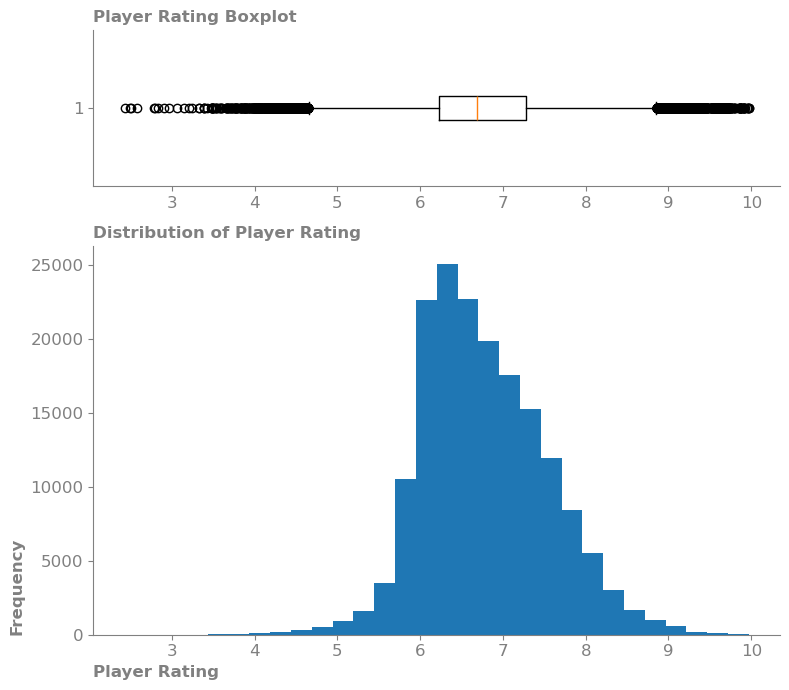

In [96]:

fig, ax = plt.subplots(
    2,1,
    figsize = (8,7),
    gridspec_kw={"height_ratios": [2, 5]})


#BoxPlot
ax[0].boxplot(
    df["player_rating"],
    vert=False
)
ax[0].set_title(
    "Player Rating Boxplot", 
    loc = 'left',
    weight = 'bold',
    fontsize = 12,
    color = 'gray')

ax[0].spines[["right","top"]].set_visible(False)
ax[0].spines[['left','bottom']].set_color('gray')

ax[0].tick_params(axis='x', labelsize='large',colors='gray')
ax[0].tick_params(axis='y', colors = 'gray', labelsize='large')




#Histogram
ax[1].hist(
    df['player_rating'],
    bins = 30
)

ax[1].set_title(
    "Distribution of Player Rating", 
    loc = 'left',
    weight = 'bold',
    fontsize = 12,
    color = 'gray')

ax[1].set_xlabel(
    "Player Rating",
    loc = 'left',
    weight = 'bold',
    fontsize = 12,
    color = 'gray'
                 )

ax[1].set_ylabel(
    "Frequency",
    loc = 'bottom',
    weight = 'bold',
    fontsize = 12,
    color = 'gray')
ax[1].spines[["right","top"]].set_visible(False)
ax[1].spines[['left','bottom']].set_color('gray')

ax[1].tick_params(axis='x', labelsize='large',colors='gray')
ax[1].tick_params(axis='y', colors = 'gray', labelsize='large')

plt.tight_layout()

plt.savefig('../Figures/Histogram&Boxplot_Player_rating')
plt.show()


## Analysis of Player Rating Distribution By Histogram

The histogram indicates that the distribution is not perfectly normal because it is not completely symmetric. However, its overall shape is relatively close to a normal distribution, suggesting that the data are approximately normally distributed.

In a perfectly normal distribution, both sides of the histogram are expected to be nearly symmetric, with frequencies decreasing at a similar rate on both sides of the peak. In this dataset, the main peak appears around the 6.2–6.5 rating range. The left side declines more rapidly, while the right side extends farther, forming a longer tail. This pattern suggests the presence of a mild to moderate positive (right) skew.

A positive skew indicates that a small number of players have exceptionally high ratings. These larger values tend to pull the mean toward the right side of the distribution. Under such conditions, the following relationship is typically observed:

Mean > Median > Mode

Therefore, the mean is expected to be slightly larger than the median.

The histogram exhibits a single prominent peak, making it a unimodal distribution. This suggests that there is no clear evidence of multiple distinct rating groups within the dataset, and most players are concentrated around a common performance level.

Regarding outliers, a histogram alone is insufficient for definitive outlier detection. However, a few observations appear near the upper range (ratings around 9–10) and lower range (ratings around 4), which may warrant further investigation. More reliable outlier detection can be performed using a box plot or the Interquartile Range (IQR) method.

The histogram also shows that most players have moderate ratings, with the majority of observations falling between 6 and 8. Very low-rated players (below 5) are relatively uncommon, while very highly rated players (above 8.5) also represent a small proportion of the dataset.

Overall, the player rating distribution can be described as approximately normal, unimodal, and mildly positively skewed, with most players clustered around average performance levels.

# Box Plot Analysis of Player Ratings

A Box Plot is used to summarize the distribution of data at a glance. The most important information provided by a box plot includes:

- Median
- First Quartile (Q1)
- Third Quartile (Q3)
- Interquartile Range (IQR)
- Outliers
- Data variability
- Skewness

In a box plot, the line inside the box represents the median. In this figure, the median is approximately 6.7. This means that about 50% of players have ratings below 6.7, while the other 50% have ratings above 6.7.

The edges of the box represent the first quartile (Q1) and third quartile (Q3). Based on the figure, Q1 is approximately 6.2 and Q3 is approximately 7.3. Therefore, the Interquartile Range (IQR) can be estimated as:

IQR = Q3 - Q1 ≈ 7.3 - 6.2 ≈ 1.1

The IQR represents the range containing the middle 50% of the observations. Therefore, approximately 50% of the players have ratings between 6.2 and 7.3. This is one of the most important insights provided by the box plot.

The black circles outside the whiskers represent outliers. Outliers are visible on both sides of the distribution. On the lower end, outliers appear roughly between 2.5 and 4.7, while on the upper end they appear approximately between 8.8 and 10.

Since the median is not positioned exactly at the center of the box, the distribution appears to exhibit some degree of skewness. This observation is consistent with the findings from the histogram.

The box itself is relatively short, indicating that the middle 50% of the observations are fairly concentrated and do not exhibit substantial variability. In other words, most players have ratings that are relatively close to one another.

Because half of the players are concentrated within the range of 6.2 to 7.3, players with very low ratings and players with very high ratings constitute a relatively small proportion of the overall population.

Overall, the box plot suggests that most players are clustered around average rating values, the central variability is relatively low, outliers exist on both sides of the distribution, and the data exhibit a slight degree of skewness.

## Consistency Between the Histogram and Box Plot

The histogram and box plot support and complement each other, providing a consistent view of the player rating distribution.

### Findings from the Histogram

The histogram indicates that:

- The distribution has a single prominent peak (unimodal distribution).
- Most player ratings are concentrated between 6 and 8.
- The distribution exhibits a slight positive (right) skew, as the right tail extends farther than the left tail.

### Findings from the Box Plot

The box plot confirms these observations by showing that:

- The median rating is approximately 6.7, indicating that the typical player rating lies near the center of the distribution.
- The interquartile range (IQR) is relatively compact, suggesting that the middle 50% of player ratings are concentrated within a fairly narrow interval.
- Outliers are present on both sides of the distribution, with a noticeable number of high-rating outliers on the right side.
- The overall variability of the data is moderate, as the central spread of the ratings is not excessively large.

### Overall Interpretation

Together, the histogram and box plot suggest that player ratings are primarily concentrated around average values, with a relatively small number of extremely low-rated or highly rated players. The distribution is approximately normal in shape but exhibits a mild positive skew, indicating that a small number of highly rated players extend the upper tail of the distribution.

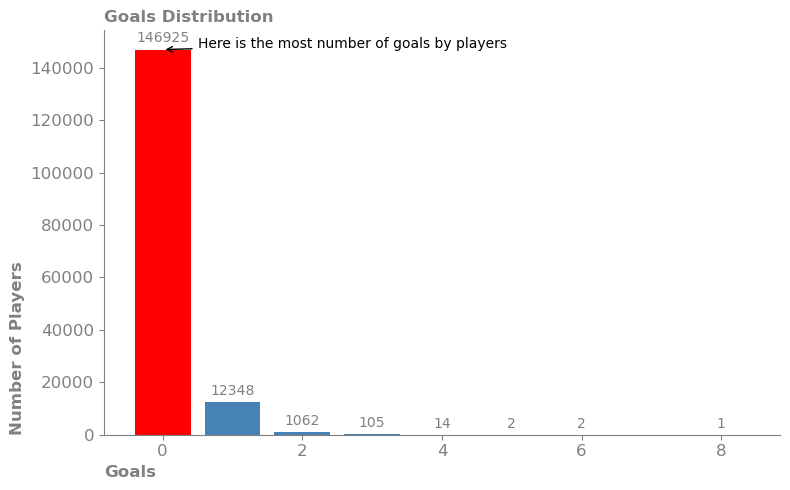

goals
0.0    146925
1.0     12348
2.0      1062
3.0       105
4.0        14
5.0         2
6.0         2
8.0         1
Name: count, dtype: int64

           GOALS ANALYSIS

Count        : 160,459
Mean         : 0.093
Median       : 0.000
Mode         : 0.0
Std Dev      : 0.321

Minimum      : 0.0
Q1 (25%)     : 0.0
Q2 (50%)     : 0.0
Q3 (75%)     : 0.0
Maximum      : 8.0

Range        : 8.0
Skewness     : 3.949




In [70]:
goal_counts = df["goals"].value_counts().sort_index()

colors = ["steelblue"] * len(goal_counts)
max_idx = goal_counts.values.argmax()
colors[max_idx] = "red"

fig, ax = plt.subplots(figsize=(8,5))

#Barplot

ax.set_title(
    "Goals Distribution", 
    loc = 'left',
    weight = 'bold',
    fontsize = 12,
    color = 'gray')

ax.set_xlabel(
    "Goals",
    loc = 'left',
    weight = 'bold',
    fontsize = 12,
    color = 'gray'
                 )

ax.set_ylabel(
    "Number of Players",
    loc = 'bottom',
    weight = 'bold',
    fontsize = 12,
    color = 'gray')

ax.spines[["right","top"]].set_visible(False)
ax.spines[['left','bottom']].set_color('gray')

bars = ax.bar(
    goal_counts.index,
    goal_counts.values,
    color=colors
)

ax.bar_label(
    bars,
    padding=3,
    fontsize=10,
    color='gray'
)

max_goal = goal_counts.idxmax()
max_count = goal_counts.max()

ax.annotate(
    f"Here is the most number of goals by players",
    xy=(max_goal, max_count),
    xytext=(max_goal + 0.5, max_count + 500),
    arrowprops=dict(arrowstyle="->")
)

ax.tick_params(axis='x', labelsize='large',colors='gray')
ax.tick_params(axis='y', colors = 'gray', labelsize='large')

plt.tight_layout()
# plt.savefig('../Figures/GoalsDisterbutionByBarplot')
plt.show()


print(goal_counts)
stats = df["goals"]

print(
f"""
========================================
           GOALS ANALYSIS
========================================

Count        : {stats.count():,}
Mean         : {stats.mean():.3f}
Median       : {stats.median():.3f}
Mode         : {stats.mode()[0]}
Std Dev      : {stats.std():.3f}

Minimum      : {stats.min()}
Q1 (25%)     : {stats.quantile(0.25)}
Q2 (50%)     : {stats.quantile(0.50)}
Q3 (75%)     : {stats.quantile(0.75)}
Maximum      : {stats.max()}

Range        : {stats.max() - stats.min()}
Skewness     : {stats.skew():.3f}

========================================
"""
)



# Analysis of the Goals Distribution by Barplot

The distribution is highly asymmetric, with the vast majority of observations concentrated on the left side of the chart. As the number of goals increases, the frequency decreases sharply.

The most prominent characteristic of this distribution is its strong positive skewness (right skewness). The distribution has a long right tail, indicating that only a small number of players scored a high number of goals. This is the defining feature of a positively skewed distribution.

The distribution is clearly non-normal. In a normal distribution, observations are expected to be distributed approximately symmetrically around the center. The presence of an extremely tall bar at zero goals followed by a rapid decline in frequency demonstrates that the data deviate substantially from a normal distribution.

The chart also exhibits a very high concentration of observations. Most players have a value of Goals = 0, meaning that the data are heavily concentrated at zero. In statistics, this pattern is commonly referred to as a High Concentration or Zero-Inflated Distribution.

Another important observation is the presence of rare events. For example, only one player scored 8 goals, while only a few players scored 5 or 6 goals. Although these values are realistic from a football perspective, their very low frequencies indicate that high-scoring performances are rare events within this dataset.

Even without performing exact calculations, it is reasonable to infer that the median is equal to zero because more than half of the players scored no goals. In contrast, the mean is expected to be greater than the median because a small number of players with relatively high goal counts pull the average toward the right tail of the distribution. This is another well-known characteristic of positively skewed distributions.

At first glance, the data may appear to have low variability because most observations are clustered near zero. However, the presence of several relatively large values on the right side indicates asymmetric dispersion, meaning that the variability is concentrated primarily in one direction rather than being evenly distributed around the center.

Overall, the chart suggests that most players did not score any goals, the number of goal-scoring players is relatively small, and players with exceptionally high goal counts represent only a very small fraction of the population.

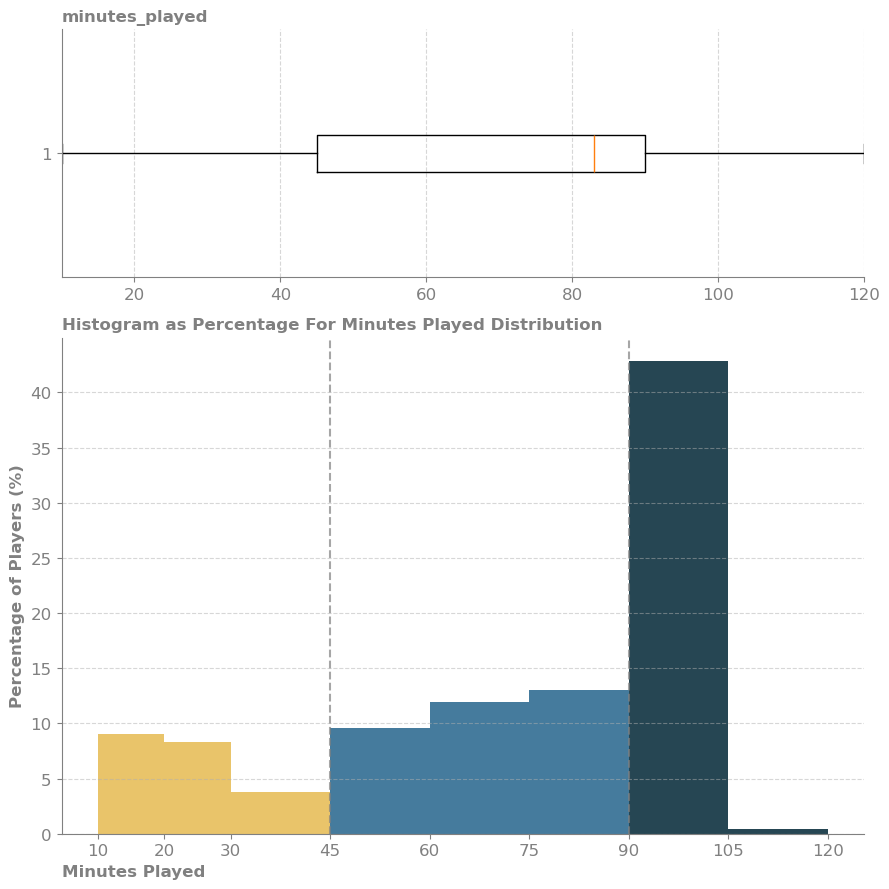

In [ ]:
bins = [10, 20, 30, 45, 60, 75, 90, 105, 120]

fig, ax = plt.subplots(2,1,
                       figsize=(9,9),
                       gridspec_kw={"height_ratios": [3,6]})

#BoxPlot
minutes_clean = df["minutes_played"].replace(
    [np.inf, -np.inf],
    np.nan
)

median_minutes = minutes_clean.median()

minutes_clean = minutes_clean.fillna(
    median_minutes
)

ax[0].boxplot(
    minutes_clean,
    vert=False
)

ax[0].set_title(
    "minutes_played", 
    loc = 'left',
    weight = 'bold',
    fontsize = 12,
    color = 'gray')

ax[0].set_xlim(10,120)
ax[0].grid(axis='x', linestyle='--', alpha=0.5)

ax[0].spines[["right","top"]].set_visible(False)
ax[0].spines[['left','bottom']].set_color('gray')

ax[0].tick_params(axis='x', labelsize='large',colors='gray')
ax[0].tick_params(axis='y', colors = 'gray', labelsize='large')

# Histogram as Percentage

n, bins, patches = ax[1].hist(
    df["minutes_played"],
    bins=bins,
    weights=np.ones(len(df)) * 100 / len(df)
)

# Coloring bins
for patch, left_edge, right_edge in zip(
    patches,
    bins[:-1],
    bins[1:]
):

    if right_edge <= 45:
        patch.set_facecolor("#E9C46A")   # زیر 45 دقیقه

    elif left_edge >= 45 and right_edge <= 90:
        patch.set_facecolor("#457B9D")   # بین 45 تا 90 دقیقه

    else:
        patch.set_facecolor("#264653")   # بیشتر از 90 دقیقه

ax[1].set_title(
    "Histogram as Percentage For Minutes Played Distribution",
    loc='left',
    weight='bold',
    fontsize=12,
    color='gray'
)

ax[1].set_xlabel(
    "Minutes Played",
    loc='left',
    weight='bold',
    fontsize=12,
    color='gray'
)

ax[1].set_ylabel(
    "Percentage of Players (%)",
    weight='bold',
    fontsize=12,
    color='gray'
)

ax[1].spines[['right','top']].set_visible(False)
ax[1].spines[['left','bottom']].set_color('gray')

ax[1].tick_params(
    axis='x',
    labelsize='large',
    colors='gray'
)

ax[1].tick_params(
    axis='y',
    labelsize='large',
    colors='gray'
)

ax[1].axvline(
    x=45,
    linestyle='--',
    color='gray',
    alpha=0.7
)

ax[1].axvline(
    x=90,
    linestyle='--',
    color='gray',
    alpha=0.7
)

ax[1].set_xticks(bins)

ax[1].grid(
    axis='y',
    linestyle='--',
    alpha=0.5
)

plt.tight_layout()

# plt.savefig('../Figures/Histogram_as_Percentage&Boxplot_For_Minutes_PlayedDistribution')
plt.tight_layout()
plt.show()

# Minutes Played Distribution Analysis

## Box Plot Analysis

The Box Plot provides several important insights into the distribution of player playing time.

* Only **25% of players** participated for **less than 45 minutes**.
* **50% of players** played between **45 and 90 minutes**, representing the middle half of the distribution.
* Therefore, at least **75% of players** were on the field for **more than one full half** of the match.

No black points (outliers) are visible in the Box Plot. According to the **1.5 × IQR rule**, no statistical outliers are detected in the `minutes_played` variable. However, this does **not** imply that a player who played 120 minutes is common. It simply means that such observations still fall within the statistically expected range of the distribution.

Although the box appears relatively long, it would be inaccurate to describe the variability as extremely high. Since the variable ranges from **10 to 120 minutes**, with:

* **Q1 ≈ 45 minutes**
* **Median ≈ 83 minutes**
* **Q3 ≈ 90 minutes**

the overall spread should be interpreted as **moderate to moderately high** rather than excessive.

The median is noticeably closer to the third quartile than to the first quartile:

* Distance from Median to Q1: **38 minutes**
* Distance from Median to Q3: **7 minutes**

This asymmetry is commonly associated with **negative skewness (left skewness)**, suggesting that the distribution is concentrated at higher values while extending further toward lower values.

---

## Histogram Analysis

The Histogram confirms and complements the findings observed in the Box Plot.

More than **40% of players** fall within the **90–105 minute** interval, indicating that a substantial proportion of players participated for nearly the entire match, including possible stoppage time or extra time.

The distribution exhibits a clear **left tail**, extending from approximately **10 to 45 minutes**. This indicates that the distribution is **negatively skewed (left-skewed)**, meaning that most observations are concentrated at higher playing times while a smaller number of players recorded substantially lower minutes.

### Distribution Shape

The histogram is **unimodal**, meaning that it contains **one dominant peak**.

* **Peak (Mode Region): 90–105 minutes**

This suggests that the most common playing time corresponds to players who remained on the field for almost the entire match.

---

## Interpretation of Player Groups

### Players with Less Than 45 Minutes

Approximately **20–25% of players** played fewer than 45 minutes.

This group likely includes:

* Substitute players
* Injured players
* Players with limited match participation

### Players Between 45 and 90 Minutes

A substantial portion of players (approximately **35%**) played between **45 and 90 minutes**.

This indicates that many players completed at least one full half of the match.

### Players Above 90 Minutes

The largest segment of the dataset consists of players who played **more than 90 minutes**.

This suggests that the majority of players in the dataset participated in nearly the entire match.

---

## Normality Assessment

The distribution cannot be considered normal for several reasons:

1. It is **not symmetric**.
2. The main peak is located near the **right side** of the distribution.
3. The distribution exhibits a **longer tail toward lower values**, indicating **negative (left) skewness**.

Therefore, the `minutes_played` variable follows a **non-normal, negatively skewed, unimodal distribution**, with a strong concentration of observations among players who remained on the field for most of the match.


## Data Preprocessing Note

Before generating the Box Plot, missing and invalid values in the `minutes_played` variable were replaced with the median value of the feature. This preprocessing step was required because Box Plot visualization cannot be produced correctly when missing or non-finite values are present. The median was chosen as a robust imputation method, and this adjustment was performed solely for visualization purposes during exploratory data analysis.

# Bivariate Analysis :

Correlation: 0.493


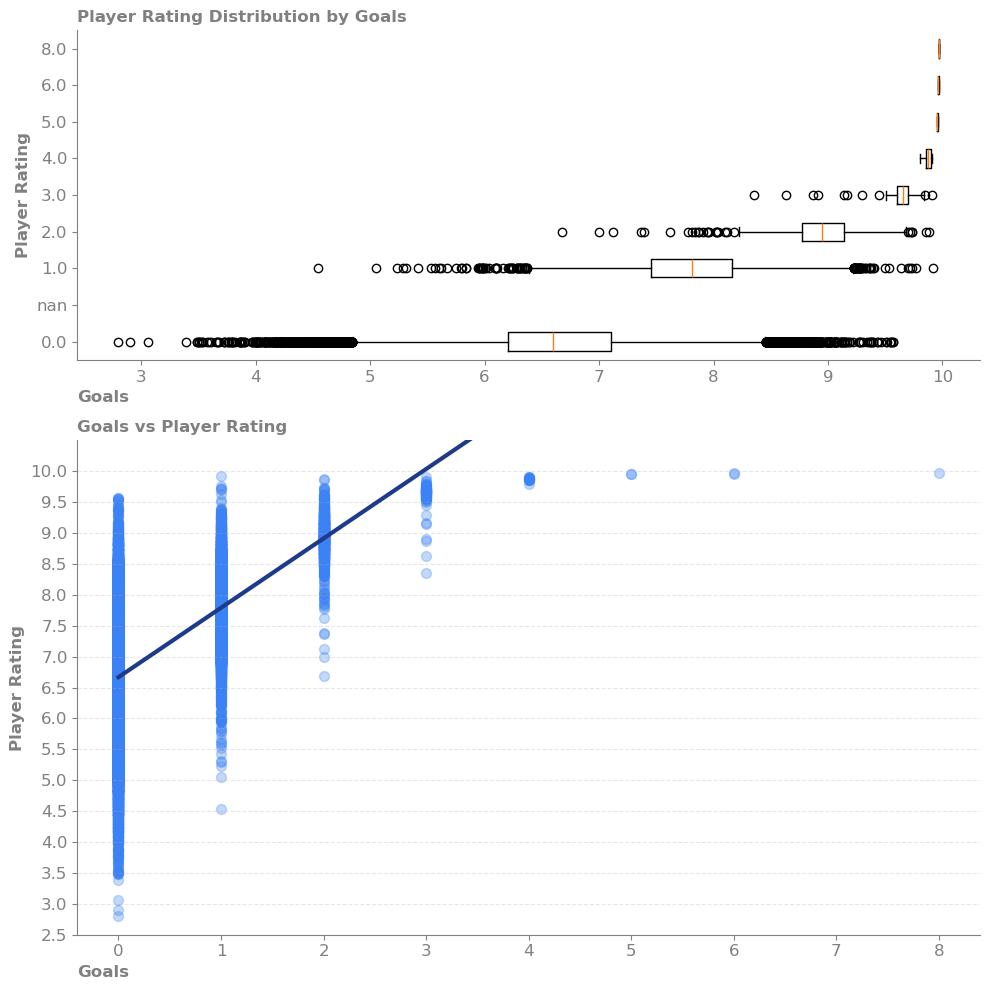

In [ ]:

fig, ax = plt.subplots(2,1,
                       figsize=(10,10),
                       gridspec_kw={"height_ratios": [4, 6]})
ax[0].boxplot(
    [
        df.loc[df["goals"] == g, "player_rating"]
        for g in sorted(df["goals"].unique())
    ],
    vert =False,
    tick_labels=sorted(df["goals"].unique())
)

ax[0].set_title(
    f"Player Rating Distribution by Goals",
    loc='left',
    weight='bold',
    fontsize=12,
    color='gray'
)

ax[0].set_xlabel(
    "Goals",
    loc='left',
    weight='bold',
    fontsize=12,
    color='gray'
)

ax[0].set_ylabel(
    "Player Rating",
    weight='bold',
    fontsize=12,
    color='gray'
)
ax[0].spines[["right","top"]].set_visible(False)
ax[0].spines[['left','bottom']].set_color('gray')


ax[0].tick_params(
    axis='x',
    labelsize='large',
    colors='gray'
)
ax[0].tick_params(
    axis='y',
    labelsize='large',
    colors='gray'
)


#Correlation 
corr = df["goals"].corr(
    df["player_rating"]
)

print(f"Correlation: {corr:.3f}")

#Regplot
sns.regplot(
    data=df,
    x="goals",
    y="player_rating",
    ax=ax[1],
    scatter_kws={
        "color": "#3B82F6",
        "alpha": 0.3,
        "s": 50
    },
    line_kws={
        "color": "#1E3A8A",
        "linewidth": 3
    }
)

ax[1].set_ylim(2.5, 10.5)
ax[1].set_yticks(np.arange(2.5, 10.5, 0.5))


ax[1].set_title(
    f"Goals vs Player Rating",
    loc='left',
    weight='bold',
    fontsize=12,
    color='gray'
)

ax[1].set_xlabel(
    "Goals",
    loc='left',
    weight='bold',
    fontsize=12,
    color='gray'
)

ax[1].set_ylabel(
    "Player Rating",
    weight='bold',
    fontsize=12,
    color='gray'
)

ax[1].spines[['right','top']].set_visible(False)
ax[1].spines[['left','bottom']].set_color('gray')

ax[1].tick_params(
    axis='x',
    labelsize='large',
    colors='gray'
)
ax[1].tick_params(
    axis='y',
    labelsize='large',
    colors='gray'
)



ax[1].grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)

plt.tight_layout()
# plt.savefig('../Figures/PlayerRatingDistribution_by_Goals_with_Boxplt&Regplot')
plt.show()



# Analysis of the Box Plot (Player Rating Distribution by Goals)

The purpose of this chart is to examine how the **distribution of player ratings across different goal-scoring levels** changes. Unlike the mean, which provides only a single summary value, a Box Plot offers a much more comprehensive view of the data distribution.

The chart clearly shows that as the number of goals increases, the median player rating also tends to increase. Players who score more goals generally receive higher ratings. This is the first indication of a positive relationship between goals scored and player ratings.

The median rating for players who scored no goals is at the lowest level, and as we move toward higher goal counts, the median line within each box gradually shifts upward. This pattern suggests that scoring more goals is generally associated with better overall performance and, consequently, higher ratings.

Another important observation is the relative reduction in rating variability at higher goal levels. Among players who scored no goals, ratings span a wide range, from relatively low to relatively high values. In contrast, players who scored multiple goals tend to have ratings concentrated within higher ranges. This suggests that goal-scoring players not only achieve higher ratings but also tend to deliver more consistent performances.

The presence of numerous outliers indicates that even among players with the same number of goals, performance levels can vary substantially. For example, some players who did not score any goals still achieved relatively high ratings, likely due to defensive contributions, playmaking ability, or other performance factors that influence player evaluation.

It is also important to note that the sample size decreases substantially as the number of goals increases. Previous frequency analysis showed that categories such as 4, 5, 6, or 8 goals contain very few observations. Therefore, although the upward trend in ratings remains visible for these groups, the results should be interpreted cautiously due to the limited sample size.

---

# Analysis of the Regplot (Goals vs Player Rating)

The purpose of this chart is to investigate the relationship between the number of goals scored and player ratings, as well as to evaluate the direction and strength of this relationship.

The blue points represent individual players, while the regression line illustrates the overall linear trend. The positive slope of the regression line indicates a positive relationship between goals scored and player ratings. In other words, as the number of goals increases, player ratings tend to increase on average.

An important observation is that the relationship is not perfectly deterministic. For example, among players with one or two goals, ratings still exhibit considerable variation. This suggests that goals scored are not the sole determinant of player ratings and that additional factors contribute to the rating system.

The heavy concentration of observations at 0, 1, and 2 goals provides further insight into the data structure. Most players fall within these categories, while players who scored more than three goals are relatively rare. Consequently, the majority of the statistical information and explanatory power of the model originates from these lower goal counts.

At the higher end of the distribution, the number of observations becomes very limited. Although these players generally achieve high ratings, the small sample size means that strong conclusions should not be drawn solely from these extreme groups.

One of the most important findings is the absence of any downward or random trend. Nearly all visual evidence suggests that player ratings increase as goals scored increase. Therefore, goals scored can be considered one of the most influential factors affecting player ratings.

---

# Why Is a Box Plot Appropriate for This Analysis?

A Box Plot is particularly useful when we want to understand:

- The median rating for each goal category.
- The variability of ratings within each group.
- Whether players with the same number of goals perform similarly.
- The location and frequency of outliers.
- How rating distributions change across different goal levels.

For these reasons, the Box Plot is one of the most effective tools for comparing rating distributions across goal-scoring groups.

---

# Why Is a Regplot Appropriate for This Analysis?

A Regplot is useful when we want to:

- Examine whether a relationship exists between two variables.
- Determine the direction of the relationship (positive or negative).
- Visualize the overall trend in the data.
- Assess the approximate strength of the association.
- Identify general patterns without focusing on individual group distributions.

In this case, the Regplot clearly demonstrates that player ratings tend to increase as the number of goals scored increases.

---

# Final Conclusion

The combination of a Box Plot and a Regplot provides a comprehensive understanding of the relationship between goals scored and player ratings. The Regplot reveals a clear positive overall trend, showing that higher goal counts are generally associated with higher player ratings. Meanwhile, the Box Plot offers deeper insights into the distribution of ratings at each goal level, highlighting changes in median values, variability, and the presence of outliers.

Taken together, the findings indicate that goals scored are an important factor influencing player ratings. Players who score more goals tend to receive higher ratings on average, and this pattern is evident both in the overall trend and within the distribution of ratings across goal categories. However, the observed variability within several groups suggests that goals alone do not fully determine player ratings, and other aspects of player performance also contribute significantly to the final evaluation.

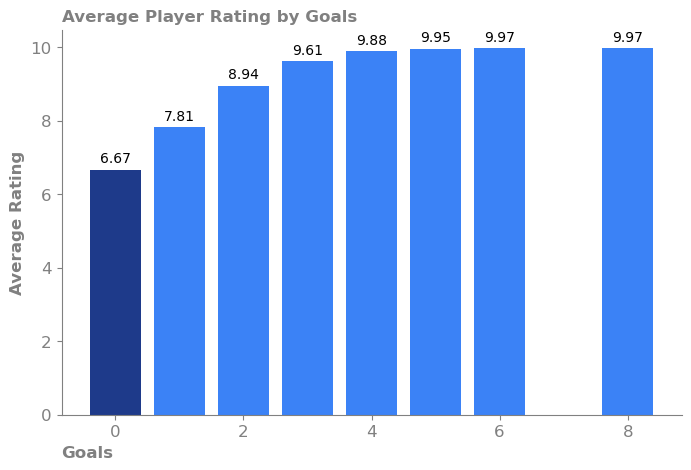

In [ ]:
mean_rating = (
    df.groupby("goals")["player_rating"]
      .mean()
)

fig, ax = plt.subplots(figsize=(8,5))

bars = ax.bar(
    mean_rating.index,
    mean_rating.values,
    color=["#1E3A8A","#3B82F6","#3B82F6","#3B82F6","#3B82F6","#3B82F6","#3B82F6","#3B82F6",]
)

ax.bar_label(
    bars,
    fmt="%.2f",
    padding=3
)


ax.set_title(
    f"Average Player Rating by Goals",
    loc='left',
    weight='bold',
    fontsize=12,
    color='gray'
)

ax.set_xlabel(
    "Goals",
    loc='left',
    weight='bold',
    fontsize=12,
    color='gray'
)

ax.set_ylabel(
    "Average Rating",
    weight='bold',
    fontsize=12,
    color='gray'
)

ax.spines[["right","top"]].set_visible(False)
ax.spines[['left','bottom']].set_color('gray')


ax.tick_params(
    axis='x',
    labelsize='large',
    colors='gray'
)
ax.tick_params(
    axis='y',
    labelsize='large',
    colors='gray'
)

# plt.savefig('../Figures/Average_Player_Rating_by_Goals')
plt.show()

# Analysis of the Average Player Rating by Goals Chart

The purpose of this chart is to examine how the **average player rating changes as the number of goals scored increases**. Unlike a Box Plot, which displays the full distribution of ratings, this chart focuses specifically on the average rating within each goal category, making it easier to identify overall trends and measure the impact of goal scoring on player evaluations.

The most obvious finding is the strong positive relationship between goals scored and average player rating. Players who did not score any goals received an average rating of approximately **6.67**, while players who scored one goal achieved an average rating of about **7.81**. This increase continues consistently as the number of goals rises.

The largest increase occurs between zero and three goals. The average rating increases from **6.67** to **9.61**, representing a substantial improvement in player evaluation. This suggests that scoring goals has a significant influence on the rating system and is one of the most heavily rewarded actions in football performance assessment.

After approximately three goals, the rate of increase begins to slow down. The average ratings for players with four, five, six, and eight goals are all clustered between **9.88** and **9.97**. This pattern indicates the presence of a practical upper limit in the rating system. Since player ratings are bounded by a maximum score, additional goals contribute less and less to the final rating once a player has already achieved an exceptional performance.

This phenomenon can be interpreted as a **diminishing returns effect**. Scoring the first goal has a large impact on the rating, scoring a second or third goal still provides substantial improvement, but beyond that point the rating approaches its ceiling and cannot increase indefinitely.

Another important observation is that the relationship appears highly monotonic. Every increase in goal count is associated with an increase in average rating. There are no decreases or irregular fluctuations between adjacent goal categories. This consistency provides strong evidence that goals are positively associated with player ratings.

However, caution is required when interpreting the categories with very high goal counts. Previous frequency analysis showed that categories such as five, six, and eight goals contain very few observations. As a result, their averages may be heavily influenced by one or two individual performances and may not be as statistically reliable as categories with larger sample sizes.

---

# What Does This Chart Tell Us?

This chart allows us to answer several important questions:

- How does player rating change as goals increase?
- Is the relationship positive or negative?
- Is the relationship linear or nonlinear?
- At what point do ratings begin to plateau?
- How strongly are goals rewarded within the rating system?

The chart clearly demonstrates that scoring goals is strongly associated with higher player ratings and that the relationship follows a positive but gradually flattening trend.

---

# Why Is This Chart Appropriate?

A bar chart of average ratings by goals is particularly useful because it summarizes a large amount of information into a simple and interpretable format.

Compared with a scatter plot, this chart removes much of the noise caused by individual observations and highlights the overall trend.

Compared with a box plot, it focuses directly on the central tendency (mean), making it easier to quantify the average effect of goal scoring on player ratings.

For exploratory data analysis (EDA), this chart is valuable because it quickly reveals whether goals have a meaningful impact on ratings and whether the relationship remains consistent across different goal categories.

---

# Key Insights

Several important conclusions can be drawn from this chart:

- Players who score more goals generally receive higher ratings.
- The relationship between goals and ratings is strongly positive.
- The largest rating improvements occur between zero and three goals.
- Rating growth slows considerably after three goals.
- Ratings appear to approach an upper limit near 10.
- The relationship is monotonic, with no decreases in average rating as goals increase.
- Categories with very high goal counts should be interpreted carefully due to their small sample sizes.

---

# Final Conclusion

This chart provides strong evidence that goals scored are one of the most influential factors affecting player ratings. As goal counts increase, average ratings increase substantially, indicating that goal-scoring performance is heavily rewarded by the rating system.

The relationship is not perfectly linear. While early increases in goals produce large improvements in average rating, the effect gradually weakens as ratings approach their maximum possible value. This creates a plateau effect at higher goal counts, where additional goals result in only marginal rating improvements.

Overall, the chart demonstrates a clear, consistent, and practically significant positive relationship between goals scored and player ratings, making it an effective tool for understanding how offensive performance contributes to player evaluation.

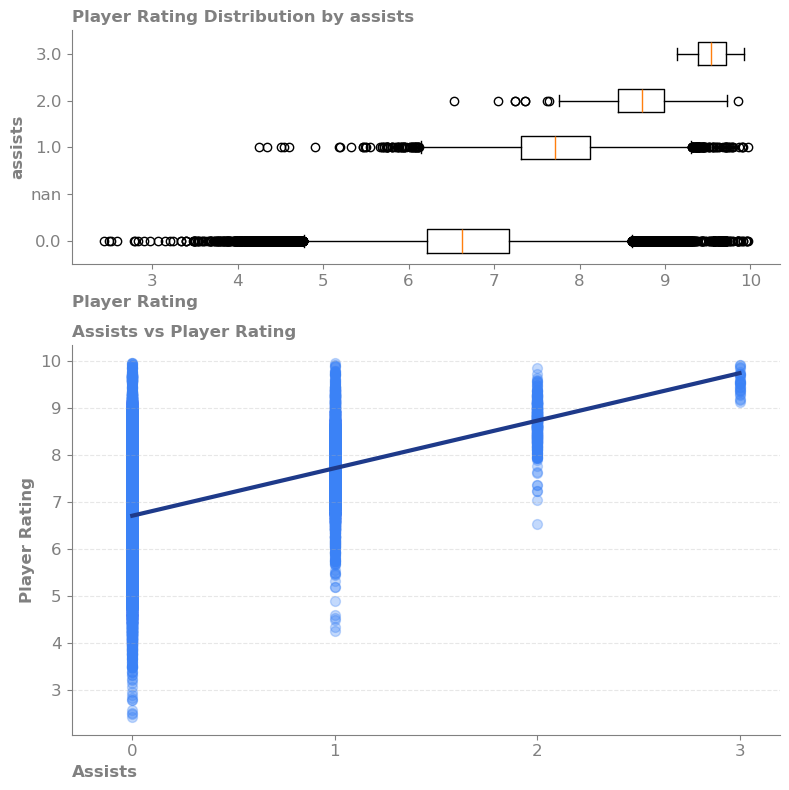

In [178]:

fig, ax = plt.subplots(2,1,
                       figsize=(8,8),
                       gridspec_kw={"height_ratios": [3, 5]})
ax[0].boxplot(
    [
        df.loc[df["assists"] == g, "player_rating"]
        for g in sorted(df["assists"].unique())
    ],
    vert =False,
    tick_labels=sorted(df["assists"].unique())
)

ax[0].set_title(
    f"Player Rating Distribution by assists",
    loc='left',
    weight='bold',
    fontsize=12,
    color='gray'
)

ax[0].set_xlabel(
    "Player Rating",
    loc='left',
    weight='bold',
    fontsize=12,
    color='gray'
)

ax[0].set_ylabel(
    "assists",
    weight='bold',
    fontsize=12,
    color='gray'
)
ax[0].spines[["right","top"]].set_visible(False)
ax[0].spines[['left','bottom']].set_color('gray')


ax[0].tick_params(
    axis='x',
    labelsize='large',
    colors='gray'
)
ax[0].tick_params(
    axis='y',
    labelsize='large',
    colors='gray'
)



#Regplot
sns.regplot(
    data=df,
    x="assists",
    y="player_rating",
    ax=ax[1],
    scatter_kws={
        "color": "#3B82F6",
        "alpha": 0.3,
        "s": 50
    },
    line_kws={
        "color": "#1E3A8A",
        "linewidth": 3
    }
)


ax[1].set_xlim(-0.3, 3.2)
ax[1].set_xticks([0, 1, 2, 3])


ax[1].set_title(
    f"Assists vs Player Rating",
    loc='left',
    weight='bold',
    fontsize=12,
    color='gray'
)

ax[1].set_xlabel(
    "Assists",
    loc='left',
    weight='bold',
    fontsize=12,
    color='gray'
)

ax[1].set_ylabel(
    "Player Rating",
    weight='bold',
    fontsize=12,
    color='gray'
)

ax[1].spines[['right','top']].set_visible(False)
ax[1].spines[['left','bottom']].set_color('gray')

ax[1].tick_params(
    axis='x',
    labelsize='large',
    colors='gray'
)
ax[1].tick_params(
    axis='y',
    labelsize='large',
    colors='gray'
)



ax[1].grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)

plt.tight_layout()
# plt.savefig('../Figures/PlayerRatingDistribution_by_Assists_with_Boxplt&Regplot')
plt.show()



# Analysis of the Box Plot and Regplot: Relationship Between Assists and Player Rating

The purpose of this analysis is to investigate whether an increase in the number of **assists** is associated with higher **player ratings**, and to understand the strength and nature of this relationship. Two complementary visualizations are used for this purpose:

1. **Box Plot** – to examine the distribution of player ratings across different assist categories.
2. **Regplot (Scatter Plot with Regression Line)** – to evaluate the overall trend and direction of the relationship between assists and player ratings.

Using these two charts together provides both a detailed view of the rating distributions and a broader understanding of the overall relationship between the variables.

---

# Analysis of the Box Plot (Player Rating Distribution by Assists)

The Box Plot illustrates how player ratings are distributed for different numbers of assists.

The most noticeable pattern is that the **median player rating consistently increases as the number of assists increases**. Players with zero assists have the lowest median rating, while players with one, two, and three assists show progressively higher median ratings.

This indicates that players who contribute directly to goal creation tend to receive higher performance ratings. Since assists are one of the most valuable offensive contributions in football, this upward trend suggests that the rating system rewards creative and playmaking actions.

Another important observation is the difference in rating variability between groups. Players with **zero assists** exhibit the widest spread of ratings, indicating substantial variation in performance levels. Some players without assists receive very low ratings, while others still achieve high ratings.

This finding is reasonable because not all player roles are expected to provide assists. Defenders, goalkeepers, and defensive midfielders may perform exceptionally well without registering an assist, yet still receive high ratings due to their defensive contributions and overall impact on the match.

As the number of assists increases, the spread of ratings becomes smaller and the ratings become increasingly concentrated in higher-value regions. This suggests that players who record multiple assists not only tend to receive higher ratings but also demonstrate more consistent performance levels.

The presence of numerous outliers across all assist categories reveals that players with the same number of assists can still receive significantly different ratings. For example, some players without assists achieve ratings close to 10, while some players with one assist receive only moderate ratings.

This observation confirms that assists are not the sole determinant of player ratings. Other performance metrics such as goals scored, key passes, passing accuracy, defensive actions, and overall match influence also contribute to the final evaluation.

Another noteworthy aspect is the decreasing number of observations in higher assist categories. Players with three assists appear much less frequently than players with zero or one assist. Consequently, although the upward trend remains visible, conclusions regarding the highest assist categories should be interpreted cautiously due to the relatively small sample sizes.

---

# Analysis of the Regplot (Assists vs Player Rating)

The Regplot provides a different perspective by examining the overall relationship between assists and player ratings.

In this chart:

- Each point represents an individual player.
- The regression line summarizes the overall trend within the data.

The most important feature of the chart is the **positive slope of the regression line**. This positive slope indicates a positive relationship between assists and player ratings. In general, as the number of assists increases, player ratings also increase.

This suggests that players who contribute more directly to creating goals tend to receive higher evaluations from the rating system.

The concentration of points around **0 and 1 assist** also provides valuable insight into the structure of the dataset. Most players fall within these categories, while players with two or three assists are relatively uncommon.

This pattern is entirely consistent with football match data, as recording multiple assists in a single game is generally a rare event.

Although the overall trend is clearly upward, substantial variation remains visible within each assist category. For instance, among players with one assist, ratings range from approximately 4 to nearly 10.

This variability indicates that the relationship is not deterministic. If assists were the only factor influencing player ratings, observations within each assist category would cluster tightly around a single value. Instead, the broad spread of points demonstrates that multiple performance dimensions contribute to player evaluations.

Another important observation is the absence of any declining or irregular trend. Both the regression line and the distributional patterns suggest that higher assist counts are consistently associated with higher player ratings.

The agreement between the Regplot and the Box Plot strengthens the evidence that assists and player ratings are positively related.

---

# Why Is the Box Plot Appropriate for This Analysis?

The Box Plot is particularly useful because it allows a comprehensive comparison of rating distributions across assist categories.

Specifically, it enables us to:

- Compare median ratings between groups.
- Evaluate rating variability and dispersion.
- Identify outliers and unusual performances.
- Examine how the entire distribution shifts as assists increase.
- Determine whether players with similar assist counts receive similar ratings.

Because the goal is not only to study average ratings but also to understand how ratings are distributed, the Box Plot is an ideal choice.

---

# Why Is the Regplot Appropriate for This Analysis?

The Regplot is highly effective for investigating relationships between two numerical variables.

It allows us to:

- Determine whether a relationship exists.
- Identify the direction of the relationship.
- Visualize the overall trend.
- Assess the approximate strength of the association.
- Detect unusual patterns or deviations from the trend.

Unlike summary statistics, the Regplot displays every observation while simultaneously highlighting the overall pattern through the regression line.

---

# Final Conclusion

The results from both visualizations support the same conclusion.

The Box Plot demonstrates that player ratings tend to increase as the number of assists increases. Median ratings shift upward across assist categories, and ratings become increasingly concentrated in higher ranges for players with more assists.

The Regplot further confirms this finding by showing a clear positive relationship between assists and player ratings. The positive slope of the regression line indicates that players who record more assists generally receive higher ratings.

However, both charts also reveal substantial variability within assist categories. Players with the same number of assists can receive very different ratings, indicating that assists are only one component of the overall evaluation process.

Therefore, while assists appear to be an important factor influencing player ratings, they do not fully explain rating variation on their own. Other performance metrics such as goals, passing quality, defensive contributions, chance creation, and overall match involvement also play significant roles in determining a player's final rating.

Overall, the analysis provides strong evidence that assists are positively associated with player ratings and represent one of the key indicators of offensive contribution and overall player performance.

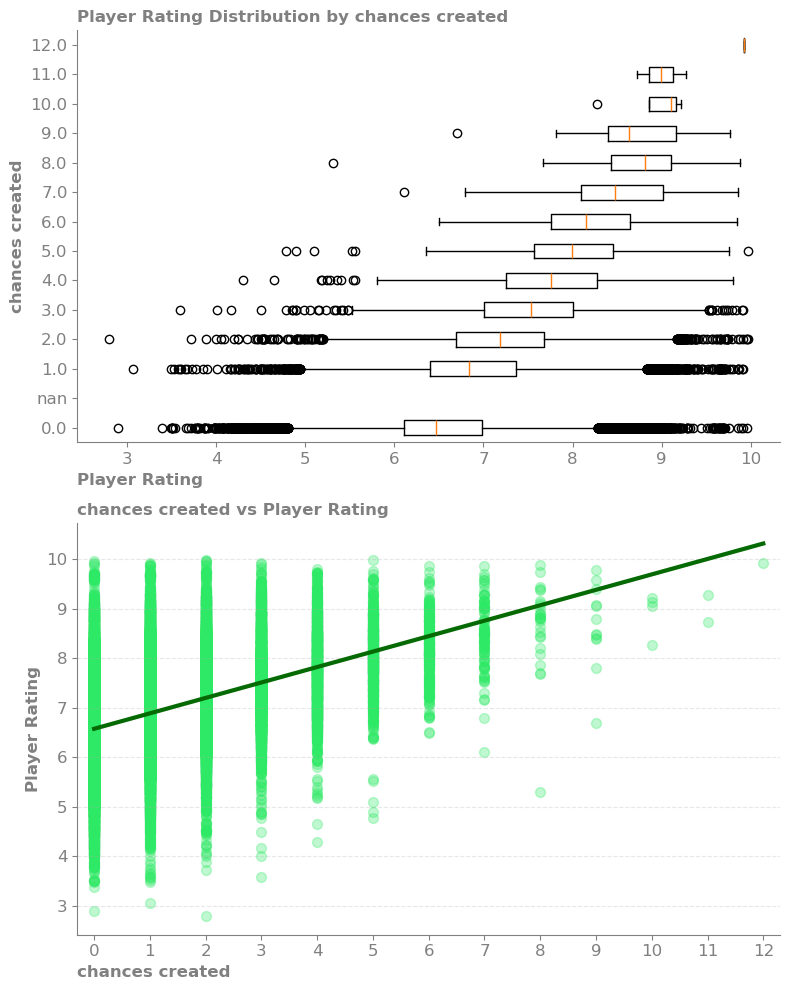

In [184]:

fig, ax = plt.subplots(2,1,
                       figsize=(8,10),
                       gridspec_kw={"height_ratios": [5, 5]})
ax[0].boxplot(
    [
        df.loc[df["chances_created"] == g, "player_rating"]
        for g in sorted(df["chances_created"].unique())
    ],
    vert =False,
    tick_labels=sorted(df["chances_created"].unique())
)

ax[0].set_title(
    f"Player Rating Distribution by chances created",
    loc='left',
    weight='bold',
    fontsize=12,
    color='gray'
)

ax[0].set_xlabel(
    "Player Rating",
    loc='left',
    weight='bold',
    fontsize=12,
    color='gray'
)

ax[0].set_ylabel(
    "chances created",
    weight='bold',
    fontsize=12,
    color='gray'
)
ax[0].spines[["right","top"]].set_visible(False)
ax[0].spines[['left','bottom']].set_color('gray')


ax[0].tick_params(
    axis='x',
    labelsize='large',
    colors='gray'
)
ax[0].tick_params(
    axis='y',
    labelsize='large',
    colors='gray'
)



#Regplot
sns.regplot(
    data=df,
    x="chances_created",
    y="player_rating",
    ax=ax[1],
    scatter_kws={
        "color": "#2DE965",
        "alpha": 0.3,
        "s": 50
    },
    line_kws={
        "color": "#056A03",
        "linewidth": 3
    }
)


ax[1].set_xlim(-0.3, 12.3)
ax[1].set_xticks(np.arange(0, 13, 1))


ax[1].set_title(
    f"chances created vs Player Rating",
    loc='left',
    weight='bold',
    fontsize=12,
    color='gray'
)

ax[1].set_xlabel(
    "chances created",
    loc='left',
    weight='bold',
    fontsize=12,
    color='gray'
)

ax[1].set_ylabel(
    "Player Rating",
    weight='bold',
    fontsize=12,
    color='gray'
)

ax[1].spines[['right','top']].set_visible(False)
ax[1].spines[['left','bottom']].set_color('gray')

ax[1].tick_params(
    axis='x',
    labelsize='large',
    colors='gray'
)
ax[1].tick_params(
    axis='y',
    labelsize='large',
    colors='gray'
)



ax[1].grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)

plt.tight_layout()
# plt.savefig('../Figures/PlayerRatingDistribution_by_chances_created_with_Boxplt&Regplot')
plt.show()



```markdown
# Analysis of the Relationship Between Chances Created and Player Rating

The purpose of this analysis is to examine whether creating more scoring opportunities (**Chances Created**) is associated with higher **Player Ratings**. Two complementary visualizations were used:

- **Box Plot** to analyze the distribution of ratings across different levels of chances created.
- **Regplot** to evaluate the overall relationship and trend between the two variables.


## Box Plot Analysis

The Box Plot shows a clear upward shift in player ratings as the number of chances created increases. Players who create more chances generally receive higher ratings, as evidenced by the steady increase in median ratings across the groups.

For players with **0 chances created**, the median rating is relatively low, while players with higher values of chances created consistently exhibit higher medians and quartiles. This indicates that chance creation is strongly associated with improved player performance evaluations.

Another important observation is that rating variability decreases at higher levels of chance creation. The boxes become narrower and more concentrated around high ratings, suggesting that players who create many opportunities tend to perform consistently well.

Several outliers are visible in most groups. Some players with no chances created still achieve high ratings, while others with multiple chances created receive lower ratings. This confirms that player ratings are influenced by additional factors such as goals, assists, passing quality, defensive actions, and other performance metrics.

It is also important to note that the number of observations decreases as chances created increases. High values such as 9–12 chances created are relatively rare, so conclusions for these groups should be interpreted with caution.


## Regplot Analysis

The Regplot provides a broader view of the relationship between the two variables.

The positive slope of the regression line clearly indicates a **positive relationship** between chances created and player rating. In general, players who create more opportunities tend to receive higher ratings.

Although the relationship is clearly positive, the points are not perfectly aligned around the regression line. This variability suggests that chances created is an important factor, but not the only determinant of player ratings.

Most observations are concentrated between **0 and 3 chances created**, while higher values occur much less frequently. This distribution is consistent with real football matches, where creating a large number of chances in a single game is uncommon.


## Why These Visualizations Are Useful

### Box Plot

The Box Plot is useful because it allows us to:

- Compare median ratings across groups.
- Examine rating variability.
- Identify outliers.
- Observe how the entire distribution changes as chances created increases.

### Regplot

The Regplot is useful because it:

- Displays all observations.
- Reveals the direction of the relationship.
- Highlights the overall trend.
- Provides a visual indication of correlation strength.


## Conclusion

Both visualizations lead to the same conclusion: **players who create more chances tend to receive higher ratings**.

The Box Plot shows that rating distributions gradually shift toward higher values as chance creation increases, while the Regplot confirms a clear positive relationship between the two variables.

Although other performance metrics also contribute to player ratings, the results suggest that **Chances Created is one of the most influential attacking metrics associated with player performance in this dataset.**
```


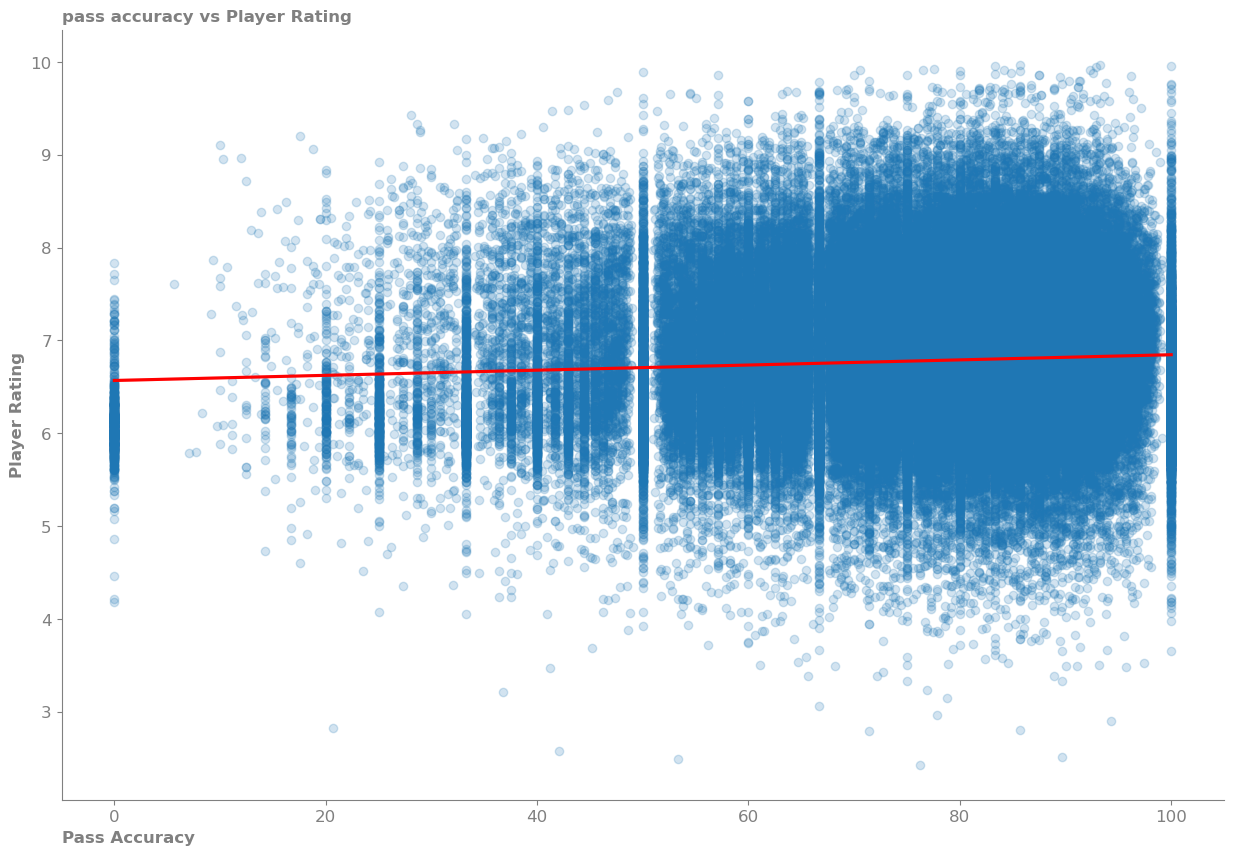

In [ ]:

fig, ax= plt.subplots(figsize=(15,10))

sns.regplot(
    data=df,
    x="pass_accuracy",
    y="player_rating",
    ax=ax,
    scatter_kws={"alpha":0.2},
    line_kws={"color":"red"}
)


ax.set_title(
    f"pass accuracy vs Player Rating",
    loc='left',
    weight='bold',
    fontsize=12,
    color='gray'
)

ax.set_xlabel(
    "Pass Accuracy",
    loc='left',
    weight='bold',
    fontsize=12,
    color='gray'
)

ax.set_ylabel(
    "Player Rating",
    weight='bold',
    fontsize=12,
    color='gray'
)

ax.spines[['right','top']].set_visible(False)
ax.spines[['left','bottom']].set_color('gray')

ax.tick_params(
    axis='x',
    labelsize='large',
    colors='gray'
)
ax.tick_params(
    axis='y',
    labelsize='large',
    colors='gray'
)



# plt.savefig('../Figures/PassAccuracy_vs_PlayerRating_by_Regplot')



plt.show()


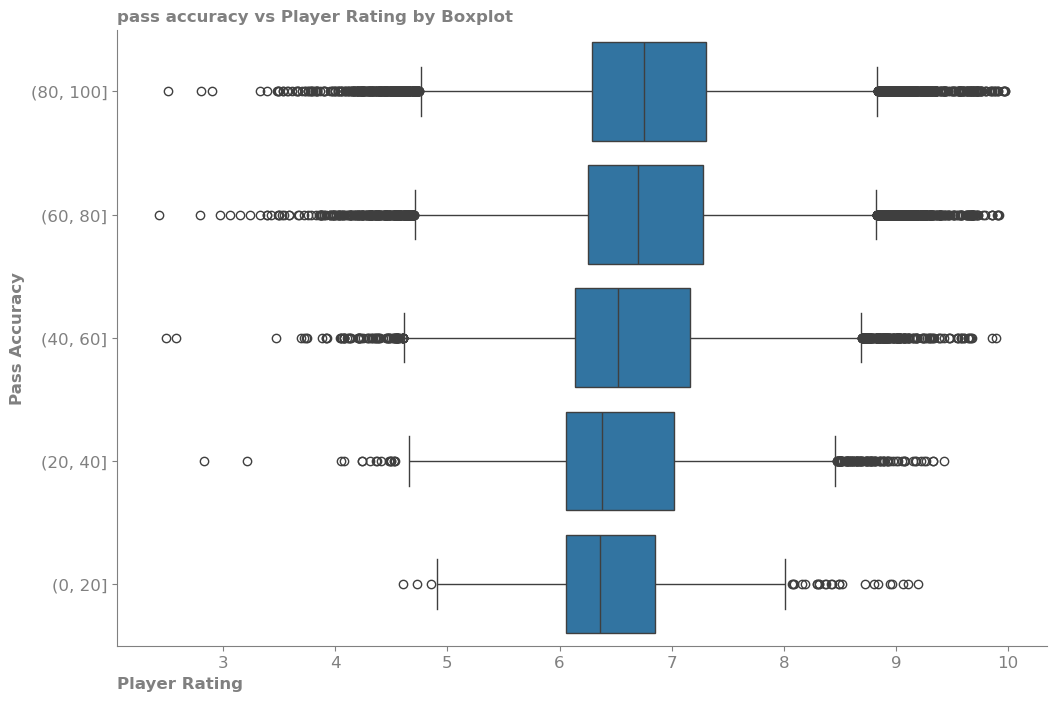

In [ ]:
fig, ax= plt.subplots(figsize=(12,8))

df["pass_group"] = pd.cut(
    df["pass_accuracy"],
    bins=[0,20,40,60,80,100]
)
order = df["pass_group"].cat.categories[::-1]
sns.boxplot(
    data=df,
    x="player_rating",
    y="pass_group",
    order=order,
    orient="h",
    ax = ax
)

ax.set_title(
    f"pass accuracy vs Player Rating by Boxplot",
    loc='left',
    weight='bold',
    fontsize=12,
    color='gray'
)

ax.set_xlabel(
    "Player Rating",
    loc='left',
    weight='bold',
    fontsize=12,
    color='gray'
)

ax.set_ylabel(
    "Pass Accuracy",
    weight='bold',
    fontsize=12,
    color='gray'
)

ax.spines[['right','top']].set_visible(False)
ax.spines[['left','bottom']].set_color('gray')

ax.tick_params(
    axis='x',
    labelsize='large',
    colors='gray'
)
ax.tick_params(
    axis='y',
    labelsize='large',
    colors='gray'
)


# plt.savefig('../Figures/PassAccuracy_vs_PlayerRating_by_Boxplott')



plt.show()



# Analysis of the Relationship Between Pass Accuracy and Player Rating

The purpose of this analysis is to examine whether higher **Pass Accuracy** is associated with higher **Player Ratings**. To investigate this relationship, both a **Box Plot** and a **Regression Plot (Regplot)** were used.

## Box Plot Analysis

The Box Plot shows the distribution of player ratings across different pass accuracy groups. A clear upward shift in the median ratings can be observed as pass accuracy increases. Players with higher pass accuracy generally receive slightly higher ratings.

The quartiles also move upward across the pass accuracy groups, indicating that the overall distribution of ratings tends to improve with better passing performance. This suggests that accurate passing contributes positively to player evaluation.

Although the median ratings increase, the spread of the distributions remains relatively similar across groups. This indicates that players with similar pass accuracy can still receive a wide range of ratings depending on other aspects of their performance.

Several outliers are visible in all groups. Some players with low pass accuracy receive high ratings, while some players with high pass accuracy receive lower ratings. This confirms that pass accuracy is only one of many factors influencing player ratings.

## Regplot Analysis

The Regplot provides a broader view of the relationship between pass accuracy and player rating. The regression line has a positive slope, indicating a positive association between the two variables.

However, the slope of the line is relatively small and the points are highly dispersed around it. This suggests that the relationship, while positive, is not particularly strong. Pass accuracy contributes to player ratings, but it does not explain most of the variation in ratings.

A large concentration of observations appears between 50% and 95% pass accuracy, which is expected in professional football where most players maintain relatively high passing accuracy.

The absence of major nonlinear patterns suggests that a simple linear trend is sufficient to describe the overall relationship.

## Why These Visualizations Are Appropriate

The **Box Plot** is useful because it allows comparison of medians, quartiles, variability, and outliers across pass accuracy groups. It helps determine whether higher pass accuracy shifts the overall distribution of player ratings.

The **Regplot** complements this analysis by displaying all observations and revealing the overall direction and strength of the relationship between the variables.

## Conclusion

Both visualizations indicate a positive relationship between pass accuracy and player ratings. Players with more accurate passing tend to receive slightly higher ratings on average. However, the considerable spread of the data and the relatively flat regression line suggest that pass accuracy alone is not a dominant predictor of player performance.

Overall, pass accuracy appears to be an important but moderate contributor to player ratings, while other performance metrics also play a significant role in determining a player's final evaluation.

C:\Users\lenovo\AppData\Local\Temp\ipykernel_32572\3586595329.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


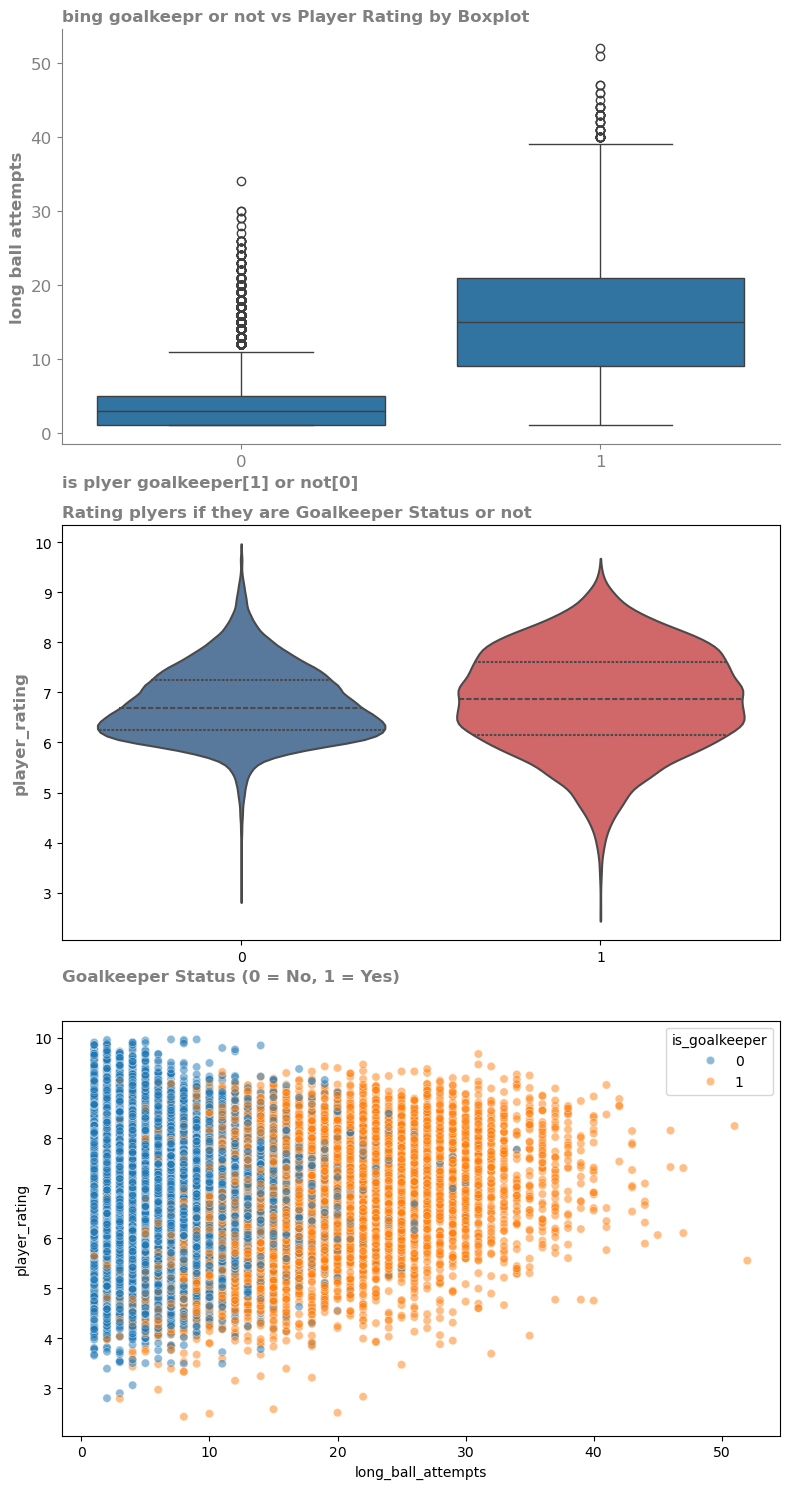

In [ ]:

fig, ax = plt.subplots(3,1,
                       figsize=(8,15),
                       gridspec_kw={"height_ratios": [5, 5, 5]})

sns.boxplot(
    x="is_goalkeeper",
    y="long_ball_attempts",
    data=df,
    ax=ax[0]
)
ax[0].set_title(
    f"bing goalkeepr or not vs Player Rating by Boxplot",
    loc='left',
    weight='bold',
    fontsize=12,
    color='gray'
)

ax[0].set_xlabel(
    "is plyer goalkeeper[1] or not[0]",
    loc='left',
    weight='bold',
    fontsize=12,
    color='gray'
)

ax[0].set_ylabel(
    "long ball attempts",
    weight='bold',
    fontsize=12,
    color='gray'
)

ax[0].spines[['right','top']].set_visible(False)
ax[0].spines[['left','bottom']].set_color('gray')

ax[0].tick_params(
    axis='x',
    labelsize='large',
    colors='gray'
)
ax[0].tick_params(
    axis='y',
    labelsize='large',
    colors='gray'
)

sns.violinplot(
    data=df,
    x="is_goalkeeper",
    y="player_rating",
    palette=["#4E79A7", "#E15759"],
    inner="quartile",
    linewidth=1.5,
    cut=0,
    ax=ax[1]
)

ax[1].set_title(
    "Rating plyers if they are Goalkeeper Status or not",
    loc="left",
    weight="bold",
    fontsize=12,
    color="gray"
)

ax[1].set_xlabel(
    "Goalkeeper Status (0 = No, 1 = Yes)",
    loc="left",
    weight="bold",
    fontsize=12,
    color="gray"
)

ax[1].set_ylabel(
    "player_rating",
    weight="bold",
    fontsize=12,
    color="gray"
)


sns.scatterplot(
    data=df,
    x="long_ball_attempts",
    y="player_rating",
    hue="is_goalkeeper",
    alpha=0.5,
    ax=ax[2]
)

# plt.savefig('../Figures/Distribution_of_LongBallAttempts&PlayerRatings_by_GoalkeeperStatus')
plt.tight_layout()
plt.show()

# Box Plot Analysis

The Box Plot was used to compare the distribution of **Long Ball Attempts** between goalkeepers and non-goalkeepers. This visualization provides valuable information about the median, quartiles, variability, and outliers within each group.

The most noticeable observation is the substantial difference between the two groups. Goalkeepers have a significantly higher median number of long ball attempts compared to non-goalkeepers. While most non-goalkeepers attempt only a few long balls during a match, goalkeepers regularly record much higher values.

This result is consistent with football tactics. Goalkeepers are often responsible for initiating play from deep areas and frequently distribute the ball directly to teammates in advanced positions. Consequently, long passes are a fundamental part of their role.

The interquartile range (IQR) is also larger for goalkeepers, indicating greater variability among them. Some goalkeepers play in possession-based teams that prefer short build-up play, while others play in more direct systems that rely heavily on long-ball distribution.

The presence of numerous outliers in both groups suggests that exceptional cases exist. Certain non-goalkeepers, such as center-backs or deep-lying playmakers, may also attempt many long passes, while some goalkeepers may record relatively few long balls due to their team's tactical approach.

Overall, the Box Plot clearly demonstrates that goalkeeper status has a strong influence on the number of long ball attempts.

---

# Violin Plot Analysis

The Violin Plot examines the distribution of **Player Ratings** for goalkeepers and non-goalkeepers. Unlike a Box Plot, which summarizes the data using quartiles and medians, the Violin Plot displays the full distribution and density of observations.

The shape of each violin indicates where observations are concentrated. Wider sections represent areas with a higher density of players, while narrower sections indicate fewer observations.

For both groups, the greatest concentration of ratings occurs between approximately 6 and 8 points. This suggests that most players, regardless of position, receive ratings within this range.

Although the distributions are broadly similar, goalkeepers appear to have a slightly higher concentration of ratings in the upper part of the distribution. Their median rating is also marginally higher, suggesting that strong goalkeeper performances are rewarded appropriately within the rating system.

The distribution tails extend toward both low and high ratings, indicating that outstanding and poor performances occur in both groups. However, the majority of observations remain concentrated around the middle range.

Overall, the Violin Plot suggests that while goalkeepers and outfield players perform different roles, their rating distributions are relatively similar, with goalkeepers showing a slight tendency toward higher ratings.

---

# Scatter Plot Analysis

The Scatter Plot explores the relationship between **Long Ball Attempts** and **Player Rating**, while simultaneously distinguishing between goalkeepers and non-goalkeepers through color coding.

A clear pattern emerges immediately: goalkeepers are concentrated on the right side of the plot, where long ball attempts are higher, whereas non-goalkeepers are mostly clustered on the left side with relatively few long passes.

This observation confirms the findings from the Box Plot and highlights the strong connection between player role and long-ball usage.

However, despite the difference in long-ball frequency, there is no strong relationship between long ball attempts and player ratings. Players with both high and low ratings can be observed across nearly all levels of long-ball activity.

This indicates that simply attempting more long passes does not necessarily lead to a higher rating. Instead, player ratings appear to be influenced by a wide range of additional performance indicators such as goals, assists, defensive actions, saves, passing quality, and overall match contribution.

The wide vertical spread of points across nearly every long-ball value supports this interpretation. If long-ball attempts were a major determinant of ratings, the points would form a much clearer upward or downward trend.

Therefore, long ball attempts appear to be more useful for identifying player roles than for predicting overall player performance.

---

# Overall Interpretation

When considered together, the three visualizations provide a comprehensive understanding of the relationship between goalkeeper status, long-ball usage, and player ratings.

The Box Plot demonstrates that goalkeepers attempt substantially more long balls than non-goalkeepers. The Violin Plot shows that the rating distributions of both groups are relatively similar, although goalkeepers exhibit a slightly higher concentration of strong ratings. The Scatter Plot further reveals that while long-ball activity strongly reflects player position, it has only a weak relationship with player ratings.

From a football analytics perspective, the most important conclusion is that **Long Ball Attempts serve primarily as a positional characteristic rather than a direct performance indicator**. Goalkeepers naturally record higher long-ball counts due to their tactical responsibilities, but these attempts alone do not explain variations in player ratings.

Consequently, long-ball statistics may be valuable for distinguishing player roles and tactical styles, but they should not be used in isolation when evaluating player performance. A complete assessment requires consideration of multiple technical and performance-related metrics alongside long-ball activity.

# Correlation Analysis :

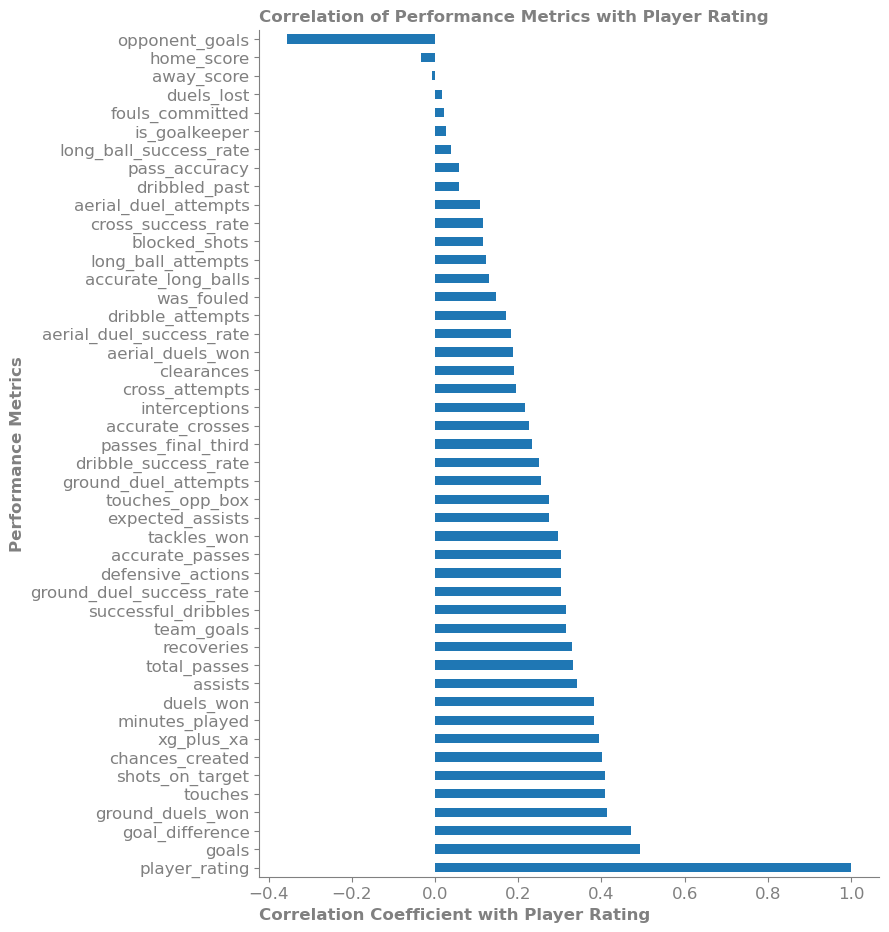

In [ ]:
numeric_cols = df.select_dtypes(
    include="number"
)

drop_cols = [
    "match_id",
    "league_id",
    "home_team_id",
    "away_team_id",
    "parent_league_season",
    "player_id",
    "team_id",
    "is_home_team"
]

numeric_cols = numeric_cols.drop(columns=drop_cols)

corr_rating = (
    numeric_cols.corr()["player_rating"]
    .sort_values(ascending=False)
)
fig, ax= plt.subplots(figsize=(8,11))

corr_rating.plot(
    kind="barh",
    ax=ax
)

ax.set_title(
    f"Correlation of Performance Metrics with Player Rating",
    loc='left',
    weight='bold',
    fontsize=12,
    color='gray'
)

ax.set_xlabel(
    "Correlation Coefficient with Player Rating",
    loc='left',
    weight='bold',
    fontsize=12,
    color='gray'
)

ax.set_ylabel(
    "Performance Metrics",
    weight='bold',
    fontsize=12,
    color='gray'
)

ax.spines[['right','top']].set_visible(False)
ax.spines[['left','bottom']].set_color('gray')

ax.tick_params(
    axis='x',
    labelsize='large',
    colors='gray'
)
ax.tick_params(
    axis='y',
    labelsize='large',
    colors='gray'
)

# plt.savefig('../Figures/Correlation_of_PerformanceMetrics_with_PlayerRating')
plt.show()

In [ ]:
styled_df = corr_rating.to_frame().style.background_gradient(
    cmap="RdYlGn"
)
# styled_df.to_excel("../Figures/Correlation_of_PerformanceMetrics_with_PlayerRating_for_AllPlayers.xlsx", engine="openpyxl")
styled_df



,player_rating
player_rating,1.000000
goal_difference,0.581416
goals,0.465260
ground_duel_success_rate,0.310989
ground_duels_won,0.259094
shots_on_target,0.244399
long_ball_attempts,0.225140
touches,0.223932
dribble_success_rate,0.223403
recoveries,0.223097


## Key Analytical Findings

One of the most important findings from the correlation analysis is that **goals** have the strongest positive relationship with **player_rating** among all performance metrics. This result is expected because scoring goals directly contributes to match outcomes and is heavily rewarded by most player rating systems.

Another important observation is the strong positive correlation between **goal_difference** and **player_rating**. Players whose teams outperform their opponents tend to receive higher ratings, suggesting that team success significantly influences individual evaluations.

Attacking metrics such as **shots_on_target**, **chances_created**, **xg_plus_xa**, **touches in the opposition box**, and **assists** also show moderate positive correlations with player ratings. This indicates that players who contribute to offensive actions and chance creation are generally rewarded with higher performance scores.

Metrics related to overall involvement in the game, including **touches**, **minutes_played**, **recoveries**, and **total_passes**, also demonstrate positive relationships with player ratings. This suggests that players who are more actively involved in match events tend to receive better evaluations.

Defensive statistics such as **duels_won**, **ground_duels_won**, **tackles_won**, **interceptions**, and **clearances** show positive but generally weaker correlations compared to attacking metrics. This does not necessarily mean that defensive actions are unimportant; rather, their impact may be diluted when all player positions are analyzed together.

On the other hand, variables such as **opponent_goals**, **duels_lost**, **fouls_committed**, and **dribbled_past** display negative correlations with player ratings. These metrics are typically associated with poorer defensive performance or unsuccessful actions, which can reduce a player's overall evaluation.

---

## Impact of Mixing Different Player Positions

An important limitation of the initial analysis is that the dataset contains players from all positions, including:

- Goalkeepers
- Defenders
- Midfielders
- Forwards

These roles have fundamentally different responsibilities and performance profiles.

For example:

- Goalkeepers rarely score goals or provide assists.
- Forwards are evaluated heavily based on goals and attacking contributions.
- Defenders are evaluated more through defensive actions and duels won.

When all positions are analyzed together, position-specific relationships become diluted, leading to weaker correlation coefficients.

---

## Why Correlations Increased After Position-Based Segmentation

To address this issue, the dataset was later divided into:

1. Goalkeepers
2. Outfield players (defenders, midfielders, and forwards)

In addition, only players who played more than **45 minutes** were included in the analysis.

After applying these filters, most correlation coefficients became stronger and more positive.

This result is statistically meaningful because:

- Players within each group perform more similar roles.
- Performance metrics become more comparable.
- Noise caused by substitute appearances is reduced.
- Relationships between actions and ratings become clearer.

For example, goals and assists become stronger predictors of ratings among outfield players, while goalkeeper-specific metrics become more informative within the goalkeeper group.

---

## Main Conclusion

The initial correlation analysis provides a useful overview of the factors associated with player ratings across all positions. The results suggest that attacking contributions, particularly goals, chance creation, and expected attacking output, are the strongest drivers of player ratings.

However, the relatively moderate correlation values observed in the full dataset indicate that mixing multiple player roles introduces substantial variability.

After separating goalkeepers from outfield players and restricting the analysis to players with more than 45 minutes played, the correlations become noticeably stronger. This demonstrates that player position and playing time are important contextual factors when evaluating performance metrics and their relationship with player ratings.

Therefore, position-specific correlation analysis provides a more accurate and interpretable understanding of what drives player performance ratings in football.

In [297]:
gk_df = df[(df['is_goalkeeper'] == 1 )& (df['minutes_played'] > 45)]
field_df = df[(df['is_goalkeeper'] == 0 )& (df['minutes_played'] > 45)]

In [293]:

numeric_cols = field_df.select_dtypes(
    include="number"
)

drop_cols = [
    "match_id",
    "league_id",
    "home_team_id",
    "away_team_id",
    "parent_league_season",
    "player_id",
    "team_id",
    "is_home_team"
]

numeric_cols = numeric_cols.drop(columns=drop_cols)

corr_rating = (
    numeric_cols.corr()["player_rating"]
    .sort_values(ascending=False)
)

corr_rating.to_frame().style.background_gradient(
    cmap="RdYlGn"
)

,player_rating
player_rating,1.000000
goal_difference,0.553318
goals,0.482578
team_goals,0.395435
shots_on_target,0.392169
xg_plus_xa,0.385146
chances_created,0.358550
assists,0.351529
ground_duels_won,0.339597
duels_won,0.334268


In [298]:

numeric_cols = gk_df.select_dtypes(
    include="number"
)

drop_cols = [
    "match_id",
    "league_id",
    "home_team_id",
    "away_team_id",
    "parent_league_season",
    "player_id",
    "team_id",
    "is_home_team"
]

numeric_cols = numeric_cols.drop(columns=drop_cols)

corr_rating = (
    numeric_cols.corr()["player_rating"]
    .sort_values(ascending=False)
)

corr_rating.to_frame().style.background_gradient(
    cmap="RdYlGn"
)

,player_rating
player_rating,1.000000
goal_difference,0.581416
goals,0.465260
ground_duel_success_rate,0.310989
ground_duels_won,0.259094
shots_on_target,0.244399
long_ball_attempts,0.225140
touches,0.223932
dribble_success_rate,0.223403
recoveries,0.223097


## Goalkeeper Correlation Analysis

For goalkeepers, the most influential variables associated with player ratings were:

| Variable | Correlation |
|-----------|------------:|
| Opponent Goals | -0.73 |
| Goal Difference | 0.58 |
| Goals | 0.47 |
| Ground Duel Success Rate | 0.31 |
| Long Ball Attempts | 0.23 |
| Touches | 0.22 |
| Recoveries | 0.22 |

### 1. Goals Conceded Are the Most Important Factor

The strongest relationship was observed between **Opponent Goals** and **Player Rating** (`r = -0.73`).

This is a very strong negative correlation, indicating that goalkeepers receive substantially lower ratings when their team concedes more goals. This finding is expected because goalkeeper evaluations are heavily influenced by:

- Clean sheets
- Goals conceded
- Shot-stopping performance

As a result, preventing goals appears to be the most critical determinant of goalkeeper ratings.

### 2. Goal Difference Has a Strong Positive Impact

**Goal Difference** showed a strong positive correlation with player ratings (`r = 0.58`).

This suggests that goalkeepers generally receive higher ratings when their team wins matches or finishes with a positive goal differential.

### 3. Long Ball Attempts Matter More for Goalkeepers

**Long Ball Attempts** demonstrated a moderate positive relationship with player ratings (`r = 0.23`).

This indicates that goalkeepers who participate more actively in the team's build-up play and distribution tend to receive higher ratings.

### 4. Passing Accuracy Is Not a Major Driver

Interestingly, **Pass Accuracy** showed a weak negative correlation (`r = -0.16`).

One possible explanation is that goalkeepers who attempt more difficult and aggressive passes—particularly long balls—may sacrifice passing accuracy while still contributing positively to overall team performance.

Therefore, overall game impact appears to be more important than raw passing accuracy for goalkeepers.

---

## Field Players Correlation Analysis

*(Defenders, Midfielders, and Forwards Combined)*

### 1. Goal Difference Remains Highly Important

**Goal Difference** remained one of the strongest predictors of player ratings (`r = 0.55`).

Players participating in successful teams generally receive higher ratings.

### 2. Goals Are the Most Important Individual Performance Metric

**Goals** showed a strong positive correlation with player ratings (`r = 0.48`).

This is expected, as scoring directly contributes to match outcomes and is heavily rewarded in most player rating systems.

### 3. Offensive Metrics Become Much More Important

Unlike goalkeepers, several attacking statistics showed strong positive relationships with ratings:

| Variable | Correlation |
|-----------|------------:|
| Shots on Target | 0.39 |
| xG + xA | 0.38 |
| Chances Created | 0.36 |
| Assists | 0.35 |

These results indicate that player ratings for field players are strongly influenced by:

- Goal scoring
- Chance creation
- Assists
- Overall attacking contribution

### 4. Duel Success Is Also Important

Several duel-related metrics displayed meaningful positive correlations:

| Variable | Correlation |
|-----------|------------:|
| Ground Duels Won | 0.34 |
| Duels Won | 0.33 |
| Ground Duel Success Rate | 0.29 |

This suggests that ratings are not solely driven by attacking output. Winning individual battles and maintaining possession also contribute significantly to player evaluations.

### 5. Touches Reflect Overall Involvement

**Touches** showed a moderate positive correlation (`r = 0.27`).

Players who are more involved in match play generally tend to receive higher ratings.

---

## Key Comparison: Goalkeepers vs Field Players

The two groups are influenced by fundamentally different performance indicators.

### Goalkeepers

The strongest rating drivers are:

- Opponent Goals
- Goal Difference
- Long Ball Attempts
- Recoveries
- Touches

### Field Players

The strongest rating drivers are:

- Goals
- Shots on Target
- Assists
- Chances Created
- xG + xA

These results clearly demonstrate that goalkeepers and field players operate in two very different performance environments, and their ratings are driven by different aspects of the game.

---

## Why Did Correlations Improve After Splitting the Dataset?

Before separating player roles, many offensive variables exhibited relatively weak correlations with player ratings.

For example:

| Variable | Full Dataset | Field Players Only |
|-----------|-------------:|-------------------:|
| Assists | ~0.09 | ~0.35 |
| Chances Created | ~0.08 | ~0.36 |
| xG + xA | ~0.03 | ~0.38 |

The reason is straightforward:

Goalkeepers almost always record:

- 0 Assists
- 0 Chances Created
- 0 xG + xA
- 0 Touches in Opponent Box
- Very few Crosses

Including goalkeepers in the same dataset introduces a large number of structural zeros, which weakens the true relationships between attacking metrics and player ratings.

After separating player roles, the real signal becomes much clearer, leading to stronger and more meaningful correlations.

This behavior is both expected and desirable, as it indicates that role-specific analysis provides a more accurate representation of the factors influencing player performance.

## Role-Specific Patterns in Player Ratings

The results suggest that player ratings in this dataset are generated from a combination of **offensive performance, defensive contribution, and match outcomes**.

For **field players (defenders, midfielders, and attackers)**, the correlations appear intuitive and consistent with real football expectations:

- Goals → Higher Rating
- Assists → Higher Rating
- Chances Created → Higher Rating
- xG + xA → Higher Rating
- Shots on Target → Higher Rating

These relationships indicate that attacking contributions are strongly rewarded within the rating system.

However, for **goalkeepers**, several correlations appear unusual:

| Variable | Correlation with Rating |
|-----------|-----------:|
| Goals | 0.46 |
| Shots on Target | 0.24 |
| Successful Dribbles | 0.20 |

From a football perspective, these relationships are difficult to interpret because goalkeepers rarely score goals, attempt shots, or complete dribbles. There are two likely explanations:

### 1. Small Goalkeeper Sample Size

The number of goalkeepers in the dataset is much smaller than the number of field players.

As a result, correlation estimates become less stable and more sensitive to a small number of unusual observations. A few extreme goalkeeper performances can significantly influence the calculated correlations.

### 2. Sparse Goalkeeper Features

Many offensive variables are almost always zero for goalkeepers, including:

- Goals
- Assists
- xG + xA
- Chances Created
- Touches in Opponent Box
- Crosses

When a feature contains little variation, correlation values can become distorted and may not reflect meaningful football relationships.

## Why Player Roles Matter

These findings strongly suggest that **player role is an important factor when modeling player ratings**.

Goalkeepers are evaluated primarily through:

- Goals conceded
- Clean sheets
- Shot stopping
- Distribution
- Defensive actions

Meanwhile, field players are evaluated through:

- Goal scoring
- Chance creation
- Assists
- Ball progression
- Defensive duels and recoveries

Because these responsibilities are fundamentally different, the factors driving player ratings are also different.

## Recommended Next Step

Instead of using only a binary classification of:

- Goalkeeper
- Non-Goalkeeper

it may be more appropriate to further separate field players into distinct role groups, such as:

- **Attack Score** (for attackers and attacking midfielders)
- **Defense Score** (for defenders and defensive-oriented players)

This approach would allow machine learning models and analytical dashboards to capture role-specific performance patterns more accurately and improve the interpretation of player ratings.
now i cleared datas and filling nall values . i did this in power bi (ETL)

In [300]:
ft_data = pd.read_excel("../Data/data_afterRemovingNullValues2.xlsx")

In [312]:
foot_data = pd.read_excel("../Data/data_afterRemovingNullValues2.xlsx")

In [302]:

#AttackScore

attack_cols = [
    "goals",
    "assists",
    "shots_on_target",
    "chances_created",
    "touches_opp_box",
    "successful_dribbles",
    "expected_assists",
    "xg_plus_xa"
]

#DefenseScore
defense_cols = [
    "tackles_won",
    "interceptions",
    "clearances",
    "defensive_actions",
    "recoveries",
    "ground_duels_won",
    "aerial_duels_won"
]



In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

ft_data[attack_cols] = scaler.fit_transform(
    ft_data[attack_cols]
)

ft_data[defense_cols] = scaler.fit_transform(
    ft_data[defense_cols]
)

ft_data["AttackScore"] = (
    ft_data[attack_cols]
    .mean(axis=1)
)
ft_data["DefenseScore"] = (
    ft_data[defense_cols]
    .mean(axis=1)
)


ft_data["RoleRatio"] = (
    ft_data["AttackScore"] /
    (ft_data["DefenseScore"] + 1e-6)
)



q25 = ft_data["RoleRatio"].quantile(0.25)
q75 = ft_data["RoleRatio"].quantile(0.75)

conditions = [
    ft_data["is_goalkeeper"] == 1,
    ft_data["RoleRatio"] > q75,
    ft_data["RoleRatio"] < q25
]

choices = [
    "Goalkeeper",
    "Attacker",
    "Defender"
]

ft_data["EstimatedRole"] = np.select(
    conditions,
    choices,
    default="Midfielder"
)

# Player Role Estimation Using Offensive and Defensive Performance Metrics

## Purpose of This Approach

The original dataset does not contain an explicit player position variable (e.g., Attacker, Midfielder, Defender). However, player roles are expected to influence performance statistics and player ratings significantly.

To better understand player behavior and create more meaningful features for Exploratory Data Analysis (EDA), Machine Learning models, and Power BI dashboards, a role estimation approach was developed based on offensive and defensive contributions.

Instead of relying on manually selected thresholds or subjective assumptions, this method uses normalized performance metrics and relative offensive-versus-defensive involvement to classify players into four estimated categories:

- Goalkeeper
- Attacker
- Midfielder
- Defender

---

# Step 1: Define Offensive and Defensive Metrics

Two groups of performance variables were selected.

### Offensive Features

```python
attack_cols = [
    "goals",
    "assists",
    "shots_on_target",
    "chances_created",
    "touches_opp_box",
    "successful_dribbles",
    "expected_assists",
    "xg_plus_xa"
]
```

These metrics represent actions directly related to attacking performance, goal creation, and offensive involvement.

### Defensive Features

```python
defense_cols = [
    "tackles_won",
    "interceptions",
    "clearances",
    "defensive_actions",
    "recoveries",
    "ground_duels_won",
    "aerial_duels_won"
]
```

These metrics capture defensive contributions such as ball recovery, tackling, and winning defensive duels.

---

# Step 2: Normalize the Data

Before combining the features, Min-Max Normalization is applied:

```python
scaler = MinMaxScaler()

ft_data[attack_cols] = scaler.fit_transform(
    ft_data[attack_cols]
)

ft_data[defense_cols] = scaler.fit_transform(
    ft_data[defense_cols]
)
```

### Why Normalization Is Necessary

The selected variables have very different scales.

For example:

| Variable | Possible Range |
|----------|---------------|
| Goals | 0–20 |
| Assists | 0–10 |
| xG+xA | 0–3 |
| Touches Opp Box | 0–50 |

Without normalization, variables with larger numerical ranges would dominate the calculation.

Min-Max Scaling transforms all variables into a common range between 0 and 1:

```text
0 ≤ Feature ≤ 1
```

This ensures that each metric contributes equally to the final score.

---

# Step 3: Create AttackScore

After normalization, an overall offensive score is calculated:

```python
ft_data["AttackScore"] = (
    ft_data[attack_cols]
    .mean(axis=1)
)
```

### Interpretation

AttackScore represents the average offensive contribution of a player across all selected attacking metrics.

A higher AttackScore indicates stronger attacking involvement.

---

# Step 4: Create DefenseScore

Similarly, a defensive score is computed:

```python
ft_data["DefenseScore"] = (
    ft_data[defense_cols]
    .mean(axis=1)
)
```

### Interpretation

DefenseScore summarizes the player's defensive contribution.

A higher DefenseScore indicates stronger defensive involvement.

---

# Step 5: Create RoleRatio

The next step compares offensive and defensive contributions directly:

```python
ft_data["RoleRatio"] = (
    ft_data["AttackScore"] /
    (ft_data["DefenseScore"] + 1e-6)
)
```

### Why Use RoleRatio?

AttackScore and DefenseScore independently describe player behavior, but they do not indicate whether a player is relatively more offensive or defensive.

RoleRatio provides that comparison.

### Examples

#### Offensive Player

```text
AttackScore  = 0.40
DefenseScore = 0.10

RoleRatio = 4.0
```

Large ratio → highly offensive player.

#### Defensive Player

```text
AttackScore  = 0.10
DefenseScore = 0.40

RoleRatio = 0.25
```

Small ratio → highly defensive player.

### Why Add `1e-6`?

```python
DefenseScore + 1e-6
```

This prevents division by zero in rare cases where DefenseScore equals zero.

---

# Why Use Quantiles Instead of Fixed Thresholds?

An earlier approach used a manually selected threshold such as:

```python
AttackScore > 1.3 * DefenseScore
```

However, this threshold is arbitrary and may not fit the actual distribution of the dataset.

Instead, the current method uses quantiles derived directly from the data.

```python
q25 = ft_data["RoleRatio"].quantile(0.25)
q75 = ft_data["RoleRatio"].quantile(0.75)
```

### Interpretation

- q25 = lower 25% of RoleRatio values
- q75 = upper 25% of RoleRatio values

This creates data-driven boundaries rather than subjective ones.

---

# Step 6: Define Role Classification Rules

```python
conditions = [
    ft_data["is_goalkeeper"] == 1,
    ft_data["RoleRatio"] > q75,
    ft_data["RoleRatio"] < q25
]
```

The classification logic is:

### Goalkeeper

```python
is_goalkeeper == 1
```

Players already identified as goalkeepers remain goalkeepers.

### Attacker

```python
RoleRatio > q75
```

Top 25% most offensive players.

### Defender

```python
RoleRatio < q25
```

Bottom 25% most defensive players.

### Midfielder

```python
default="Midfielder"
```

Players falling between the offensive and defensive extremes.

These players typically contribute to both phases of play.

---

# Step 7: Generate Estimated Roles

```python
ft_data["EstimatedRole"] = np.select(
    conditions,
    choices,
    default="Midfielder"
)
```

This creates a new categorical variable:

```text
Goalkeeper
Attacker
Midfielder
Defender
```

for every player in the dataset.

---

# Why This Approach Was Chosen

This method was selected because:

- It is entirely data-driven.
- It avoids subjective role assignments.
- It uses actual player performance statistics.
- It adapts automatically to the dataset distribution.
- It produces interpretable player-role estimates.
- It creates useful features for EDA, dashboards, and machine learning.

Compared with fixed thresholds, quantile-based classification is more robust and better reflects the underlying structure of the data.

---

# Key Result

The most important output of this process is not the final role label itself, but the three derived features:

- **AttackScore**
- **DefenseScore**
- **RoleRatio**

These variables capture much richer information about player behavior than a simple categorical role.

For example:

```text
AttackScore = 0.72
DefenseScore = 0.18
RoleRatio = 4.00
```

contains significantly more information than simply labeling the player as:

```text
Attacker
```

For this reason:

- **AttackScore**, **DefenseScore**, and **RoleRatio** are valuable features for Machine Learning models.
- **EstimatedRole** is especially useful for EDA, visualization, and Power BI dashboards.

Overall, this approach provides a structured and data-driven way to approximate player roles while preserving important information about each player's offensive and defensive profile.

In [323]:
ft_data["EstimatedRole"].value_counts()

EstimatedRole
Midfielder    85846
Attacker      43277
Defender      31322
Goalkeeper    13142
Name: count, dtype: int64

In [330]:
foot_data = foot_data.merge(
        ft_data[
        ["match_id",
         "player_id",
         "EstimatedRole",
         "AttackScore",
         "DefenseScore"]
    ],
    on=["match_id","player_id"],
    how= "left"
)

In [ ]:
Goalkeeper = foot_data[foot_data['EstimatedRole']=="Goalkeeper"]
Attacker = foot_data[foot_data['EstimatedRole']=="Attacker"]
Defender = foot_data[foot_data['EstimatedRole']=="Defender"]
Midfielder = foot_data[foot_data['EstimatedRole']=="Midfielder"]

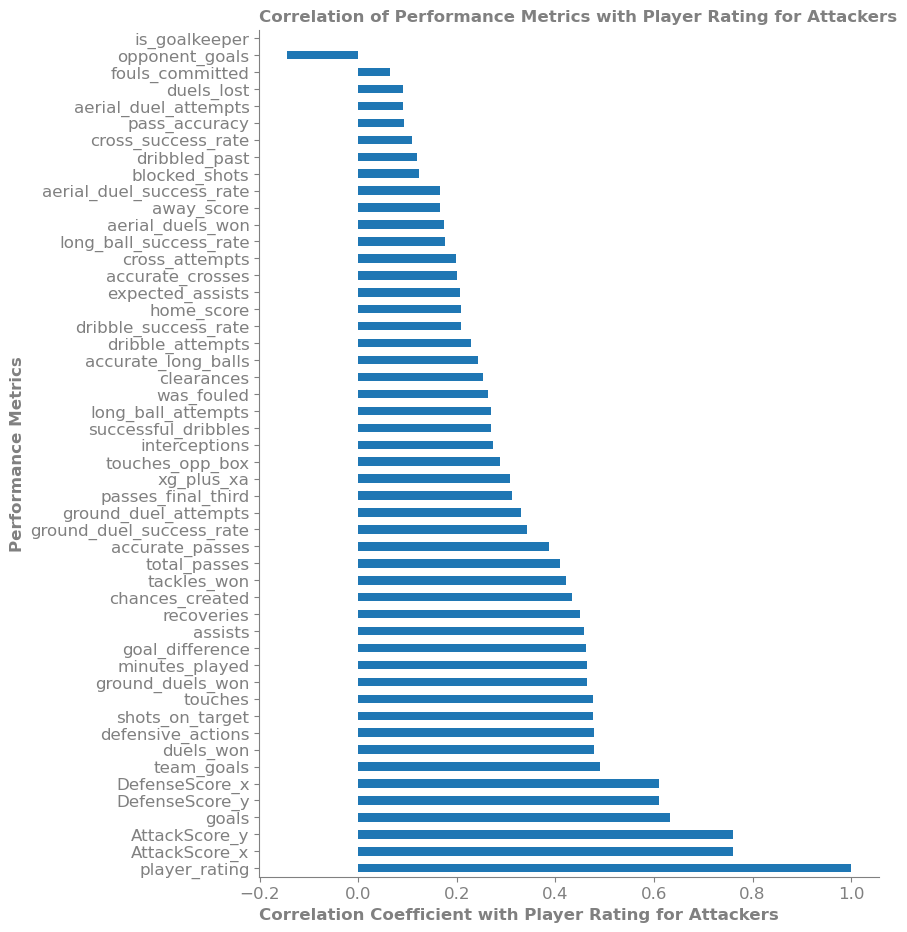

In [ ]:
numeric_cols = Attacker.select_dtypes(
    include="number"
)

drop_cols = [
    "match_id",
    "league_id",
    "home_team_id",
    "away_team_id",
    "parent_league_season",
    "player_id",
    "team_id",
    "is_home_team"
]

numeric_cols = numeric_cols.drop(columns=drop_cols)

corr_rating = (
    numeric_cols.corr()["player_rating"]
    .sort_values(ascending=False)
)
fig, ax= plt.subplots(figsize=(8,11))

corr_rating.plot(
    kind="barh",
    ax=ax
)

ax.set_title(
    f"Correlation of Performance Metrics with Player Rating for Attackers",
    loc='left',
    weight='bold',
    fontsize=12,
    color='gray'
)

ax.set_xlabel(
    "Correlation Coefficient with Player Rating for Attackers",
    loc='left',
    weight='bold',
    fontsize=12,
    color='gray'
)

ax.set_ylabel(
    "Performance Metrics",
    weight='bold',
    fontsize=12,
    color='gray'
)

ax.spines[['right','top']].set_visible(False)
ax.spines[['left','bottom']].set_color('gray')

ax.tick_params(
    axis='x',
    labelsize='large',
    colors='gray'
)
ax.tick_params(
    axis='y',
    labelsize='large',
    colors='gray'
)

# plt.savefig('../Figures/Correlation_of_PerformanceMetrics_with_PlayerRating_for_Attackers')
plt.show()

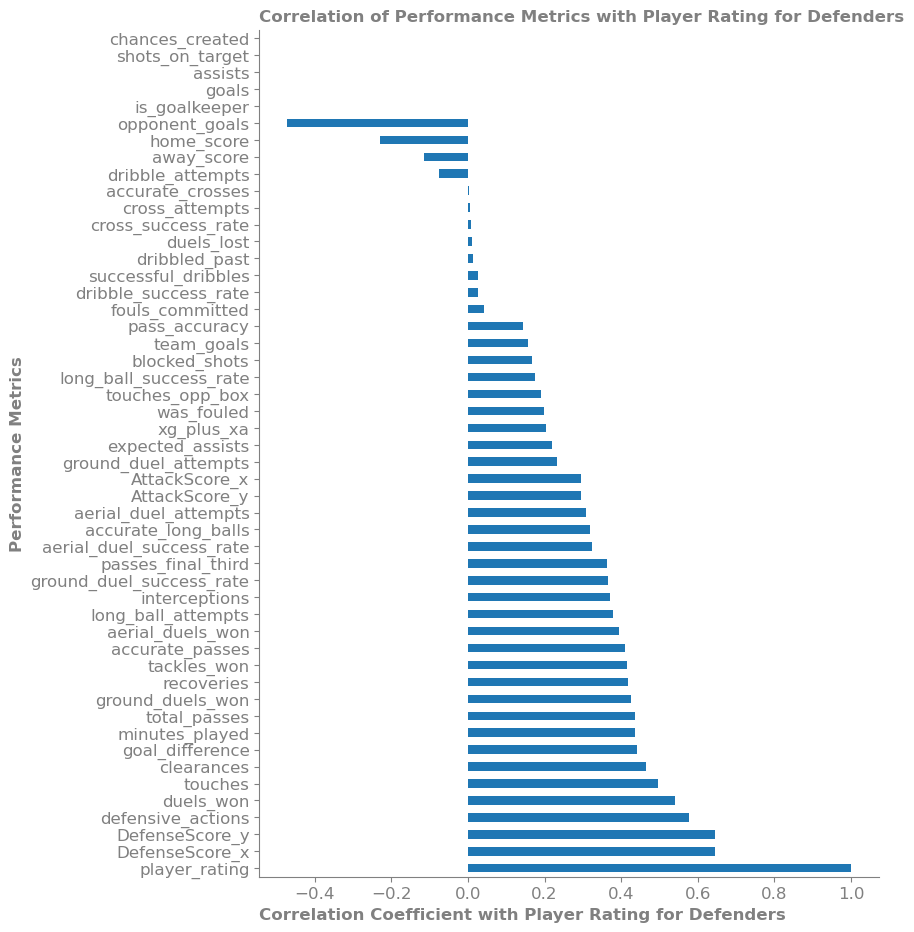

In [ ]:
numeric_cols = Defender.select_dtypes(
    include="number"
)

drop_cols = [
    "match_id",
    "league_id",
    "home_team_id",
    "away_team_id",
    "parent_league_season",
    "player_id",
    "team_id",
    "is_home_team"
]

numeric_cols = numeric_cols.drop(columns=drop_cols)

corr_rating = (
    numeric_cols.corr()["player_rating"]
    .sort_values(ascending=False)
)
fig, ax= plt.subplots(figsize=(8,11))

corr_rating.plot(
    kind="barh",
    ax=ax
)

ax.set_title(
    f"Correlation of Performance Metrics with Player Rating for Defenders",
    loc='left',
    weight='bold',
    fontsize=12,
    color='gray'
)

ax.set_xlabel(
    "Correlation Coefficient with Player Rating for Defenders",
    loc='left',
    weight='bold',
    fontsize=12,
    color='gray'
)

ax.set_ylabel(
    "Performance Metrics",
    weight='bold',
    fontsize=12,
    color='gray'
)

ax.spines[['right','top']].set_visible(False)
ax.spines[['left','bottom']].set_color('gray')

ax.tick_params(
    axis='x',
    labelsize='large',
    colors='gray'
)
ax.tick_params(
    axis='y',
    labelsize='large',
    colors='gray'
)

# plt.savefig('../Figures/Correlation_of_PerformanceMetrics_with_PlayerRating_for_Defenders')
plt.show()

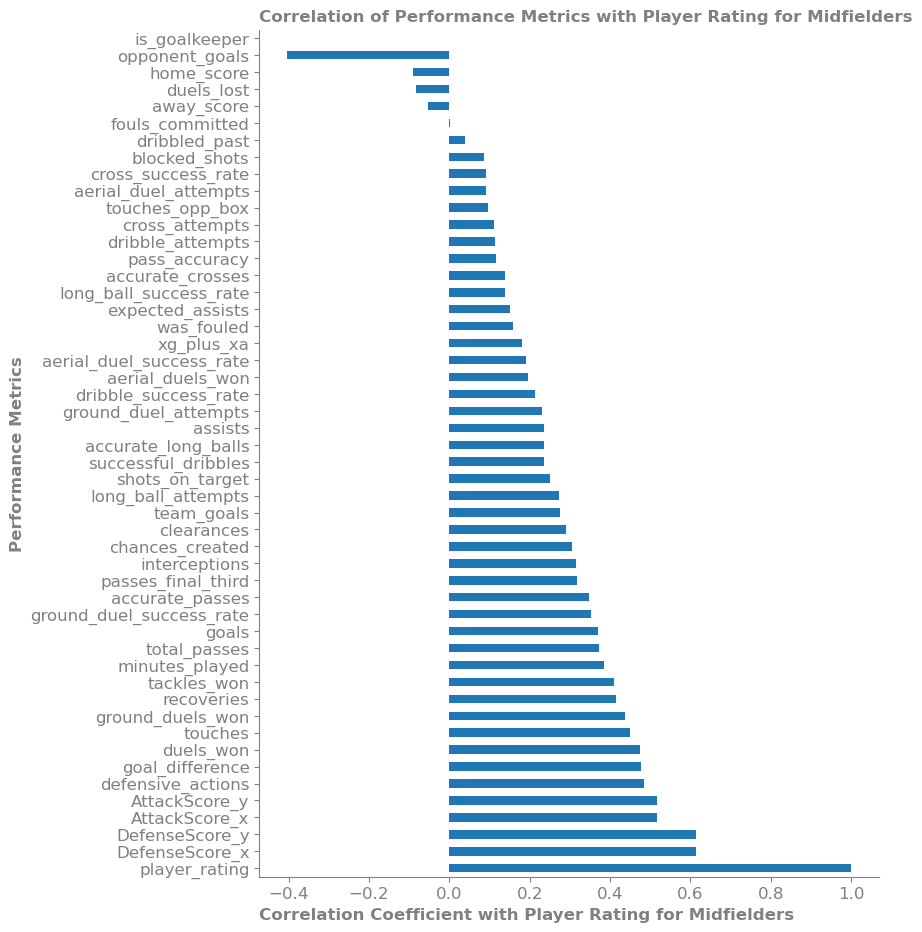

In [ ]:
numeric_cols = Midfielder.select_dtypes(
    include="number"
)

drop_cols = [
    "match_id",
    "league_id",
    "home_team_id",
    "away_team_id",
    "parent_league_season",
    "player_id",
    "team_id",
    "is_home_team"
]

numeric_cols = numeric_cols.drop(columns=drop_cols)

corr_rating = (
    numeric_cols.corr()["player_rating"]
    .sort_values(ascending=False)
)
fig, ax= plt.subplots(figsize=(8,11))

corr_rating.plot(
    kind="barh",
    ax=ax
)

ax.set_title(
    f"Correlation of Performance Metrics with Player Rating for Midfielders",
    loc='left',
    weight='bold',
    fontsize=12,
    color='gray'
)

ax.set_xlabel(
    "Correlation Coefficient with Player Rating for Midfielders",
    loc='left',
    weight='bold',
    fontsize=12,
    color='gray'
)

ax.set_ylabel(
    "Performance Metrics",
    weight='bold',
    fontsize=12,
    color='gray'
)

ax.spines[['right','top']].set_visible(False)
ax.spines[['left','bottom']].set_color('gray')

ax.tick_params(
    axis='x',
    labelsize='large',
    colors='gray'
)
ax.tick_params(
    axis='y',
    labelsize='large',
    colors='gray'
)

# plt.savefig('../Figures/Correlation_of_PerformanceMetrics_with_PlayerRating_for_Midfielders')
plt.show()

In [355]:
Goalkeeper[Goalkeeper["minutes_played"]>45]["minutes_played"].describe()

count    12957.000000
mean        89.931774
std          4.074007
min         46.000000
25%         90.000000
50%         90.000000
75%         90.000000
max        120.000000
Name: minutes_played, dtype: float64

## Goalkeeper Correlation Analysis

To investigate whether low playing time was affecting the correlation analysis for goalkeepers, a filter was applied to include only goalkeepers who played more than 45 minutes.

The results showed that only **185 records (approximately 1.4% of goalkeeper observations)** were removed after applying the filter. In addition, the average playing time increased only slightly from **89.13 minutes** to **89.93 minutes**. This indicates that the vast majority of goalkeepers in the dataset had already played a full match (90 minutes).

Therefore, the weak correlations observed for goalkeeper-related variables cannot be attributed to insufficient playing time.

Several factors may explain this outcome:

* The dataset does not contain many goalkeeper-specific performance metrics such as:

  * Saves
  * Save Percentage
  * Clean Sheets
  * Goals Prevented

* The player rating formula for goalkeepers may be influenced more strongly by match-level outcomes, particularly:

  * Opponent Goals
  * Goal Difference

  This observation is supported by the correlation analysis, where these variables exhibited the strongest relationships with goalkeeper ratings.

* Pearson correlation measures only linear relationships. Consequently, it may not adequately capture more complex or non-linear effects of variables such as:

  * Long Ball Attempts
  * Recoveries
  * Defensive Actions

In conclusion, filtering goalkeepers by playing time did not significantly change the dataset characteristics. The relatively weak correlations are more likely related to the absence of specialized goalkeeper statistics and the limitations of linear correlation analysis rather than the amount of time played.


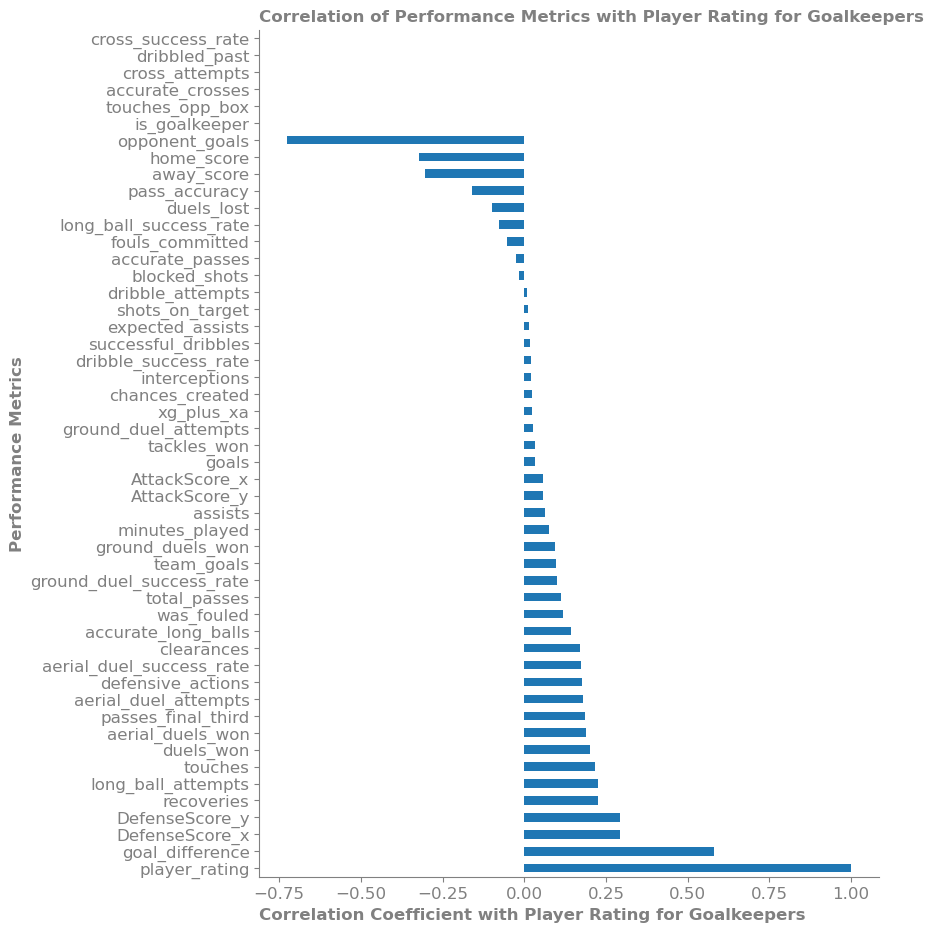

In [ ]:
Goalkeeper = Goalkeeper[Goalkeeper['minutes_played'] > 45]
numeric_cols = Goalkeeper.select_dtypes(
    include="number"
)

drop_cols = [
    "match_id",
    "league_id",
    "home_team_id",
    "away_team_id",
    "parent_league_season",
    "player_id",
    "team_id",
    "is_home_team"
]

numeric_cols = numeric_cols.drop(columns=drop_cols)

corr_rating = (
    numeric_cols.corr()["player_rating"]
    .sort_values(ascending=False)
)
fig, ax= plt.subplots(figsize=(8,11))

corr_rating.plot(
    kind="barh",
    ax=ax
)

ax.set_title(
    f"Correlation of Performance Metrics with Player Rating for Goalkeepers",
    loc='left',
    weight='bold',
    fontsize=12,
    color='gray'
)

ax.set_xlabel(
    "Correlation Coefficient with Player Rating for Goalkeepers",
    loc='left',
    weight='bold',
    fontsize=12,
    color='gray'
)

ax.set_ylabel(
    "Performance Metrics",
    weight='bold',
    fontsize=12,
    color='gray'
)

ax.spines[['right','top']].set_visible(False)
ax.spines[['left','bottom']].set_color('gray')

ax.tick_params(
    axis='x',
    labelsize='large',
    colors='gray'
)
ax.tick_params(
    axis='y',
    labelsize='large',
    colors='gray'
)

# plt.savefig('../Figures/Correlation_of_PerformanceMetrics_with_PlayerRating_for_Goalkeeper')
plt.show()

# Correlation Analysis by Estimated Player Roles

To better understand the factors influencing player ratings, players were first categorized into four estimated roles:

- Goalkeeper
- Defender
- Midfielder
- Attacker

After assigning these roles, the correlation between each performance metric and `player_rating` was calculated separately within each role group. This approach produced significantly more meaningful results than analyzing all players together because each position contributes to the game in fundamentally different ways.

---

# Attacker Analysis

The strongest features correlated with player ratings among attackers were:

- AttackScore_x
- AttackScore_y
- Goals
- Team Goals
- Shots on Target
- Touches
- Duels Won
- Defensive Actions
- Goal Difference
- Assists
- Recoveries
- Chances Created

These findings are highly intuitive and consistent with real football performance.

Attackers are primarily evaluated based on their offensive contributions. Therefore, players who:

- Score goals
- Create chances
- Provide assists
- Produce shots on target

naturally receive higher ratings.

The presence of:

- Goals
- Shots on Target
- Assists
- Chances Created

among the strongest correlations confirms that the rating system rewards direct offensive impact.

An interesting observation is that **Pass Accuracy** shows only a relatively weak relationship with ratings for attackers. This is also logical because attackers are not expected to maintain extremely high passing accuracy. For example, a striker may have:

```text
Pass Accuracy = 65%
Goals = 2
```

and still receive an excellent rating due to decisive attacking contributions.

---

# Defender Analysis

The strongest variables for defenders were:

- Defensive Actions
- Goal Difference
- Touches
- Clearances
- Duels Won
- Recoveries
- Tackles Won
- Interceptions

These results align closely with the responsibilities of a successful defender.

A high-performing defender is expected to:

- Win tackles
- Recover possession
- Clear dangerous balls
- Win defensive duels
- Break up opposition attacks

Therefore, it is reasonable that defensive statistics dominate the correlation rankings.

Another important observation is that offensive metrics such as:

- Goals
- Assists
- Shots on Target

have little influence on defender ratings.

This finding reinforces earlier visual analyses and confirms that scoring goals is not the primary factor used to evaluate defenders. Their ratings are largely driven by defensive effectiveness rather than offensive output.

---

# Midfielder Analysis

The strongest correlations for midfielders were observed in:

- AttackScore
- DefenseScore
- Goal Difference
- Touches
- Duels Won
- Recoveries
- Tackles Won
- Minutes Played
- Passes
- Pass Accuracy
- Interceptions
- Chances Created

These results reflect the hybrid nature of the midfield role.

Midfielders are expected to contribute in both attacking and defensive phases of the game. They must:

- Support attacks
- Retain possession
- Distribute the ball
- Create chances
- Defend when required
- Control the flow of play

Because of these responsibilities, both offensive and defensive metrics influence midfielder ratings.

This explains why the correlation profile of midfielders is more balanced than that of attackers or defenders.

---

# Goalkeeper Analysis

The strongest features for goalkeepers were:

- Goal Difference
- Opponent Goals

These results are understandable given the structure of the dataset.

The dataset does not contain specialized goalkeeper statistics such as:

- Saves
- Save Percentage
- Clean Sheets
- Goals Prevented

As a result, the rating system relies on indirect indicators of goalkeeper performance.

Variables such as:

- Opponent Goals
- Goal Difference

serve as proxies for overall goalkeeping success.

This limitation explains why goalkeeper correlations appear weaker and less informative compared to those of outfield players.

---

# Overall Conclusion

The role-based segmentation proved to be a highly effective analytical decision.

When all players were analyzed together, many meaningful relationships were diluted because different positions contribute to the game in different ways. By separating players into:

- Goalkeepers
- Defenders
- Midfielders
- Attackers

the underlying performance patterns became much clearer.

The results demonstrate that:

- Attackers are primarily rewarded for offensive production.
- Defenders are primarily rewarded for defensive effectiveness.
- Midfielders are rewarded for a balanced combination of offensive and defensive contributions.
- Goalkeeper ratings are largely influenced by team-level outcomes due to the absence of specialized goalkeeping metrics.

Overall, this role-based analysis provides a more realistic representation of football performance and reveals how the rating system evaluates players according to the responsibilities of their position.

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

X = Attacker.drop(columns=[
    "player_rating",
    "player_id",
    "match_id",
    "team_id",
    "league_id",
    "match_date",
    "player_name",
    "team_name",
    "league_name",
    "home_team_id",
    "away_team_id",
    "AttackScore_x",
    "AttackScore_y",
    "DefenseScore_x",
    "DefenseScore_y"
], errors="ignore")

X = X.select_dtypes(include="number")


y = Attacker["player_rating"]


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)



model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

pred = model.predict(X_test)

print(r2_score(y_test, pred))

0.9280858286823247


In [ ]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})
importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(20))

                     Feature  Importance
9                      goals    0.402424
10                   assists    0.250317
16                   touches    0.093921
44  ground_duel_success_rate    0.060903
15           chances_created    0.043962
6            goal_difference    0.040263
31                recoveries    0.010699
34                duels_lost    0.009248
8             minutes_played    0.008276
11           shots_on_target    0.005683
33                 duels_won    0.004156
21              total_passes    0.003989
46             pass_accuracy    0.003688
5             opponent_goals    0.003663
20           accurate_passes    0.003562
41      dribble_success_rate    0.003436
17           touches_opp_box    0.003308
30         defensive_actions    0.003302
45  aerial_duel_success_rate    0.003047
14                xg_plus_xa    0.002922


In [368]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# حذف Feature های مهندسی شده و ID ها

cols_to_remove = [
    "AttackScore_x",
    "AttackScore_y",
    "DefenseScore_x",
    "DefenseScore_y",
    "player_id",
    "match_id",
    "team_id",
    "league_id",
    "home_team_id",
    "away_team_id",
    "goals",
    "assists",
    "goal_difference"

]

X2 = Attacker.drop(
    columns=cols_to_remove + ["player_rating"],
    errors="ignore"
)

# فقط ستون های عددی
X2 = X2.select_dtypes(include="number")

# متغیر هدف
y = Attacker["player_rating"]

# تقسیم داده
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2,
    y,
    test_size=0.2,
    random_state=42
)

# ساخت مدل
model2 = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

# آموزش مدل
model2.fit(X_train2, y_train2)

# پیش بینی
pred2 = model2.predict(X_test2)

# ارزیابی
print("R² Score:", r2_score(y_test2, pred2))

R² Score: 0.7501955818407658


In [369]:
importance2 = pd.DataFrame({
    "Feature": X2.columns,
    "Importance": model2.feature_importances_
})

importance2 = importance2.sort_values(
    by="Importance",
    ascending=False
)

print(importance2.head(20))

                     Feature  Importance
4                 team_goals    0.237160
7             minutes_played    0.125952
8            shots_on_target    0.104238
27         defensive_actions    0.075777
12           chances_created    0.068332
41  ground_duel_success_rate    0.064015
13                   touches    0.032765
5             opponent_goals    0.029640
30                 duels_won    0.025789
28                recoveries    0.024715
11                xg_plus_xa    0.016921
31                duels_lost    0.016330
43             pass_accuracy    0.015414
18              total_passes    0.012588
14           touches_opp_box    0.010706
17           accurate_passes    0.010671
10          expected_assists    0.008604
32          ground_duels_won    0.008579
19        passes_final_third    0.008551
33      ground_duel_attempts    0.007544



The model achieved an R² score of 0.93 using all available football performance metrics. To evaluate feature dependency, Goals, Assists, and Goal Difference were removed and the model was retrained. The R² score decreased to 0.75, indicating that although these features are highly influential, the model can still explain a large portion of player ratings using other performance indicators such as Shots on Target, Chances Created, Passing Metrics, and Duel Success Rates.

## Machine Learning Model Development and Feature Analysis for Attacker

During the machine learning phase, a **Random Forest Regressor** was used to predict the **Player Rating** variable. Initially, all numerical features related to player performance were included as input variables, while only identifier columns (IDs), text columns (player names, team names, league names), and the target variable (`player_rating`) were removed. After training the model, an **R² score of approximately 0.93** was achieved, indicating excellent predictive performance.

However, a high R² score alone does not necessarily mean that the model has learned meaningful football-related patterns. One of the most important steps in evaluating a machine learning model is understanding which features the model relies on when making predictions. For this reason, the **Feature Importance** functionality of the Random Forest algorithm was used. This metric measures the contribution of each feature to the model's decision-making process.

The initial Feature Importance analysis revealed that the variables `AttackScore_x`, `AttackScore_y`, `DefenseScore_x`, and `DefenseScore_y` had a disproportionately large influence on the model. This observation was important because these variables were manually engineered by combining several existing football statistics. For example, the Attack Score was derived from metrics such as goals, assists, chance creation, and other offensive indicators.

As a result, these engineered variables contained information that was already present in the original features. Keeping both the engineered features and their underlying components could lead the model to repeatedly use similar information. While this is not technically considered data leakage, it can artificially inflate model performance and make feature importance analysis less reliable.

To investigate this issue, a second experiment was conducted. The variables `AttackScore_x`, `AttackScore_y`, `DefenseScore_x`, and `DefenseScore_y` were removed from the feature set, and the model was retrained.

After removing these engineered features, the R² score remained almost unchanged, decreasing only slightly from approximately **0.932 to 0.928**. This result was highly informative because it demonstrated that the model's strong performance was not solely dependent on the engineered scores. Instead, the model was able to learn meaningful patterns directly from the underlying football statistics. In other words, the model genuinely relied on player performance metrics rather than being heavily dependent on Attack Score and Defense Score.

Following this step, Feature Importance was evaluated again. The most influential features became:

- Goals
- Assists
- Touches
- Ground Duel Success Rate
- Chances Created
- Goal Difference

From a football perspective, this outcome is entirely reasonable. For attacking players, goals and assists have a direct impact on performance ratings. However, this raised another important question:

**Was the model truly learning complex football-related patterns, or was it achieving high performance primarily because of highly influential variables such as goals and assists?**

To answer this question, a third experiment was performed. In addition to removing Attack Score and Defense Score, the following variables were also excluded from the feature set:

- `goals`
- `assists`
- `goal_difference`

These variables were selected because they exhibited both the highest correlation with Player Rating and the highest Feature Importance values in the previous model. Therefore, they were likely responsible for a significant portion of the model's predictive power.

After removing these key variables, the model was retrained. The R² score decreased from approximately **0.93 to 0.75**. This decline was expected because some of the most informative offensive metrics had been removed. Nevertheless, the model was still able to explain approximately **75% of the variance in Player Rating**.

This finding suggests that player ratings are not determined solely by goals and assists. Other performance-related metrics also contribute significantly to the evaluation of a player's performance.

The new Feature Importance analysis identified the following variables as the most influential predictors:

- Team Goals
- Minutes Played
- Shots on Target
- Defensive Actions
- Chances Created
- Ground Duel Success Rate
- Touches
- Recoveries
- Duels Won

From a football analytics perspective, these results are highly meaningful. Even when an attacker does not score a goal, factors such as shot accuracy, chance creation, involvement in possession, success in duels, and defensive contribution can significantly influence their overall match rating.

Therefore, the model demonstrated an ability to capture broader aspects of player performance beyond basic goal-scoring statistics.

Overall, the purpose of progressively removing features was not to create a final model without them. Instead, the objective was to better understand the model's behavior and evaluate its dependence on specific variables.

These experiments led to several important conclusions:

1. The engineered features (Attack Score and Defense Score) were not essential to the model's performance, as their removal caused only a negligible decrease in accuracy.
2. Goals, assists, and goal difference are the strongest predictors of attacker ratings.
3. Even after removing these highly influential variables, the model maintained acceptable predictive performance and was still able to explain a large proportion of rating variability.
4. The model relies not only on direct scoring statistics but also on more complex football indicators such as chance creation, involvement in play, duel success, and defensive contribution.

### Interpretation of the R² Metric

The **R² score (Coefficient of Determination)** measures the proportion of variance in the target variable that can be explained by the model.

In general:

- **R² < 0.30** → Poor predictive performance
- **0.30 ≤ R² < 0.50** → Moderate performance
- **0.50 ≤ R² < 0.70** → Good performance
- **0.70 ≤ R² < 0.85** → Very good performance
- **R² ≥ 0.85** → Excellent predictive performance

Therefore, both models produced strong results:

- **Full Model:** R² ≈ 0.93
- **Reduced Model (without Goals, Assists, and Goal Difference):** R² ≈ 0.75

These findings indicate that the dataset contains substantial predictive information and is well suited for forecasting player ratings using machine learning techniques.

## Data Leakage Considerations

During the model development process, special attention was paid to avoiding **Data Leakage**.

Data Leakage occurs when information that would not be available at prediction time is unintentionally included in the training data. This can lead to unrealistically high evaluation scores because the model gains access to information that directly or indirectly reveals the target variable.

For example, if a feature is derived from the target variable itself or contains future information that would not be known when making a prediction, the model may appear highly accurate during evaluation but fail to generalize to new data.

In this project, identifier columns (such as player IDs, match IDs, team IDs, and league IDs) were removed because they do not represent player performance and could introduce unwanted patterns. Additionally, engineered features such as Attack Score and Defense Score were separately evaluated to ensure that the model was not overly dependent on aggregated metrics derived from other football statistics.

To further investigate feature dependency, several highly influential variables (Goals, Assists, and Goal Difference) were temporarily removed and the model was retrained. Although the model performance decreased, it still achieved a strong R² score, indicating that the model was learning meaningful football-related patterns rather than relying on a small number of dominant variables.

These experiments increased confidence that the model's predictions were based on genuine performance indicators and were not significantly affected by data leakage.

In [372]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    model2,
    X2,
    y,
    cv=5,
    scoring="r2"
)

print("Fold Scores:", scores)
print("Mean R²:", scores.mean())

Fold Scores: [0.72012265 0.74327951 0.7273945  0.77432806 0.74656263]
Mean R²: 0.7423374688489278


To obtain a more robust estimate of model performance, 5-fold cross-validation was performed.

The model achieved fold R² scores of:

0.720, 0.743, 0.727, 0.774, and 0.747

with an average R² of 0.742.

The relatively small variation between folds indicates that the model generalizes consistently across different subsets of the data and is not heavily dependent on a particular train-test split.

In [374]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

X = Midfielder.drop(columns=[
    "player_rating",
    "player_id",
    "match_id",
    "team_id",
    "league_id",
    "home_team_id",
    "away_team_id",
    "match_date",
    "player_name",
    "team_name",
    "league_name",
    "AttackScore_x",
    "AttackScore_y",
    "DefenseScore_x",
    "DefenseScore_y"
], errors="ignore")

X = X.select_dtypes(include="number")

y = Midfielder["player_rating"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

pred = model.predict(X_test)

print("R² Score:", r2_score(y_test, pred))

R² Score: 0.8387860199039591


In [ ]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(20))

                     Feature  Importance
6            goal_difference    0.201270
30         defensive_actions    0.184918
44  ground_duel_success_rate    0.103500
9                      goals    0.088524
16                   touches    0.061763
31                recoveries    0.046189
5             opponent_goals    0.035952
15           chances_created    0.029655
33                 duels_won    0.027981
10                   assists    0.021068
34                duels_lost    0.015250
21              total_passes    0.015245
8             minutes_played    0.014951
45  aerial_duel_success_rate    0.011875
46             pass_accuracy    0.010061
20           accurate_passes    0.008608
28             interceptions    0.008080
26        long_ball_attempts    0.007486
22        passes_final_third    0.007423
29                clearances    0.006425


In [381]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

X = Midfielder.drop(columns=[
    "player_rating",
    "player_id",
    "match_id",
    "team_id",
    "league_id",
    "home_team_id",
    "away_team_id",
    "match_date",
    "player_name",
    "team_name",
    "league_name",
    "AttackScore_x",
    "AttackScore_y",
    "DefenseScore_x",
    "DefenseScore_y",
    "goal_difference",
    "defensive_actions",
    "ground_duel_success_rate"
], errors="ignore")

X = X.select_dtypes(include="number")

y = Midfielder["player_rating"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

pred = model.predict(X_test)

print("R² Score:", r2_score(y_test, pred))

R² Score: 0.8281667023713968


In [378]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(20))

                 Feature  Importance
6        goal_difference    0.201920
30     defensive_actions    0.183822
9                  goals    0.088052
33             duels_won    0.084875
16               touches    0.065341
34            duels_lost    0.054352
31            recoveries    0.042851
5         opponent_goals    0.033611
15       chances_created    0.030329
35      ground_duels_won    0.022387
10               assists    0.019868
8         minutes_played    0.016968
45         pass_accuracy    0.010653
21          total_passes    0.009886
41  dribble_success_rate    0.009317
20       accurate_passes    0.009043
28         interceptions    0.007969
22    passes_final_third    0.007548
26    long_ball_attempts    0.007278
29            clearances    0.006252


In [382]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring="r2"
)

print("Fold Scores:", scores)
print("Mean R²:", scores.mean())
print("Std:", scores.std())

Fold Scores: [0.8024055  0.80873981 0.80902847 0.85239289 0.79584912]
Mean R²: 0.813683157069641
Std: 0.01994885813550266


# Midfielder Model Analysis

For the **Midfielder** group, a **Random Forest Regressor** was initially trained using all available features. After training, **Feature Importance** was analyzed to identify which variables contributed the most to predicting player ratings.

The initial results showed that the most influential features were:

- Goal Difference (0.20)
- Defensive Actions (0.18)
- Ground Duel Success Rate (0.10)
- Goals (0.09)
- Touches (0.06)
- Recoveries (0.05)

From a football perspective, these results are highly reasonable. Unlike attackers, whose ratings are often heavily influenced by goals and assists, midfielders contribute in many different areas of the game. Their performance depends not only on offensive involvement but also on defensive contributions, ball possession, playmaking, and success in duels. Therefore, it is expected that variables such as **Defensive Actions**, **Recoveries**, **Touches**, and **Ground Duel Success Rate** appear among the most important predictors of player ratings.

The initial model achieved the following performance using a standard **Train/Test Split**:

```text
R² = 0.839
```

This means that the model was able to explain approximately **84% of the variation in Player Rating**, which is considered a very strong result for football performance data. Since many factors affecting player ratings are not explicitly recorded in the dataset, achieving this level of predictive power indicates that the model successfully captured meaningful patterns within the available statistics.

## Feature Removal Experiment

After reviewing the feature importance results, an important question emerged:

> Is the model overly dependent on a small number of highly influential features?

To investigate this, the three most important features were removed:

- Goal Difference
- Defensive Actions
- Ground Duel Success Rate

The model was then retrained and evaluated again.

The results were:

```text
Before Removal: R² = 0.839
After Removal : R² = 0.828
```

The decrease of approximately **0.01** in R² is very small and does not represent a significant loss in predictive performance.

This finding is important because it indicates that the model is **not relying exclusively on these three variables**. Instead, it is able to extract useful information from many other performance metrics. If the model's R² had dropped dramatically (for example, from 0.84 to 0.50), it would have suggested a strong dependency on a small subset of features. However, this was not the case.

The experiment demonstrates that information related to midfielder performance is distributed across multiple variables, allowing the model to make reliable predictions using a broader representation of player performance.

After removing the top features, several other variables became more influential, including:

- Duels Won
- Duels Lost
- Touches
- Recoveries
- Chances Created
- Ground Duels Won

This suggests that the model successfully identified alternative patterns and relationships within the data rather than depending solely on a few dominant variables.

## Cross-Validation Analysis

To further evaluate model stability and generalization ability, **5-Fold Cross Validation** was performed.

The results were:

```text
Fold Scores:
0.802
0.809
0.809
0.852
0.796

Mean R² = 0.814
Std = 0.020
```

The average R² value of **0.814** indicates that the model consistently explains more than **81% of the variance in Player Rating** across different subsets of the data.

This result is very close to the Train/Test Split score, suggesting that the model's performance is stable and not dependent on a specific data split.

The standard deviation is:

```text
Std = 0.020
```

A standard deviation of only 0.02 is relatively small, meaning that the model performs consistently across all folds. This indicates that the model is not highly sensitive to the particular train/test partition and demonstrates strong generalization capability.

In other words, the model did not achieve good performance by chance on a favorable split of the data. Instead, it appears to have learned meaningful and transferable patterns.

## Interpreting R² Scores

For regression problems, the following guidelines are often used when interpreting R² values:

| R² Score | Interpretation |
|-----------|---------------|
| Below 0.30 | Weak model |
| 0.30 – 0.50 | Moderate performance |
| 0.50 – 0.70 | Good performance |
| 0.70 – 0.85 | Very good performance |
| Above 0.85 | Excellent performance |

Based on these guidelines:

```text
Train/Test R² = 0.839
Cross Validation Mean R² = 0.814
```

Both results fall within the **Very Good** performance range.

Another important observation is the small difference between the Train/Test score and the Cross Validation score:

```text
0.839 - 0.814 = 0.025
```

A difference of approximately **2.5%** is generally considered acceptable and does not indicate severe overfitting.

If the model had achieved a very high Train/Test score (for example, 0.95) but a much lower Cross Validation score (for example, 0.60), that would suggest overfitting. However, since both values are close to each other, the model appears to generalize well to unseen data.

## Conclusion

Overall, the Midfielder model demonstrates both **strong predictive performance** and **good stability**.

The feature removal experiment showed that:

1. The model is not heavily dependent on a small number of variables.
2. Performance remains strong even after removing the most influential features.
3. Multiple football-related statistics contribute to rating prediction.
4. The model learns meaningful patterns from a broad range of performance indicators rather than relying solely on a few dominant metrics.

These results increase confidence in the model and suggest that **Player Rating for midfielders can be effectively predicted using a diverse set of football performance statistics**.

In [388]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

X = Defender.drop(columns=[
    "player_rating",
    "player_id",
    "match_id",
    "team_id",
    "league_id",
    "home_team_id",
    "away_team_id",
    "match_date",
    "player_name",
    "team_name",
    "league_name",
    "AttackScore_x",
    "AttackScore_y",
    "DefenseScore_x",
    "DefenseScore_y"
], errors="ignore")

X = X.select_dtypes(include="number")

y = Defender["player_rating"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

pred = model.predict(X_test)

print("R² Score:", r2_score(y_test, pred))

R² Score: 0.8159471147250196


In [385]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(20))

                     Feature  Importance
30         defensive_actions    0.314021
5             opponent_goals    0.240003
6            goal_difference    0.059617
44  ground_duel_success_rate    0.053091
8             minutes_played    0.040135
31                recoveries    0.038999
16                   touches    0.035855
33                 duels_won    0.029222
34                duels_lost    0.024909
21              total_passes    0.019461
46             pass_accuracy    0.012636
20           accurate_passes    0.010896
45  aerial_duel_success_rate    0.010866
28             interceptions    0.009627
26        long_ball_attempts    0.009279
22        passes_final_third    0.008925
29                clearances    0.007402
43    long_ball_success_rate    0.007007
4                 team_goals    0.006083
36      ground_duel_attempts    0.005615


In [386]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

X = Defender.drop(columns=[
    "player_rating",
    "player_id",
    "match_id",
    "team_id",
    "league_id",
    "home_team_id",
    "away_team_id",
    "match_date",
    "player_name",
    "team_name",
    "league_name",
    "AttackScore_x",
    "AttackScore_y",
    "DefenseScore_x",
    "DefenseScore_y",
    "defensive_actions",
    "opponent_goals",
    "goal_difference"
], errors="ignore")

X = X.select_dtypes(include="number")

y = Defender["player_rating"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

pred = model.predict(X_test)

print("R² Score:", r2_score(y_test, pred))

R² Score: 0.7836601319964445


In [387]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(20))

                     Feature  Importance
14                   touches    0.196293
30                 duels_won    0.119251
1                 home_score    0.091647
3               is_home_team    0.090739
2                 away_score    0.076492
41  ground_duel_success_rate    0.055938
27                clearances    0.047770
6             minutes_played    0.044365
28                recoveries    0.039037
4                 team_goals    0.034928
31                duels_lost    0.030058
26             interceptions    0.025225
43             pass_accuracy    0.015302
19              total_passes    0.012093
18           accurate_passes    0.011894
24        long_ball_attempts    0.011476
20        passes_final_third    0.010404
25               tackles_won    0.010390
42  aerial_duel_success_rate    0.010235
40    long_ball_success_rate    0.008896


In [389]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring="r2"
)

print("Fold Scores:", scores)
print("Mean R²:", scores.mean())
print("Std:", scores.std())

Fold Scores: [0.70300641 0.75453545 0.78995054 0.83869345 0.79089954]
Mean R²: 0.7754170786128878
Std: 0.04502038412388439


# Defender Model Analysis

For the **Defender** players, a Random Forest Regressor model was initially trained using all available performance-related features, excluding identifier columns (IDs), names, and the engineered features `AttackScore` and `DefenseScore`. The purpose of this stage was to evaluate the model's ability to predict **Player Rating** based on real defensive performance statistics.

The initial model achieved the following result using the Train/Test Split approach:

```text
R² = 0.816
```

This indicates that the model was able to explain approximately **81.6% of the variance in player ratings**. For football performance data, this is considered a very strong result and suggests a substantial relationship between player statistics and the final rating.

---

## Feature Importance Analysis

After training the model, Feature Importance was examined to identify which variables contributed most to the prediction process.

The most important features were:

- Defensive Actions (0.314)
- Opponent Goals (0.240)
- Goal Difference (0.060)
- Ground Duel Success Rate (0.053)
- Minutes Played (0.040)
- Recoveries (0.039)
- Touches (0.036)
- Duels Won (0.029)

These results are highly consistent with football logic. Unlike attackers, whose ratings are often heavily influenced by goals and assists, defenders are generally evaluated based on their ability to prevent opposition attacks, win defensive duels, and contribute to the team's defensive success.

The presence of **Defensive Actions** as the most important feature is expected because it directly measures a player's involvement in defensive activities. Similarly, **Opponent Goals** ranking second is also meaningful from a football perspective; conceding fewer goals generally reflects stronger defensive performances and therefore higher player ratings.

Additionally, variables such as **Goal Difference**, **Recoveries**, **Ground Duel Success Rate**, and **Duels Won** are all key indicators of defensive quality. Therefore, the initial Feature Importance results align well with football knowledge and expectations.

---

## Dependency Analysis Through Feature Removal

After observing the initial Feature Importance results, an important question emerged:

> Is the model overly dependent on a few dominant features?

To investigate this, the three most influential features were removed:

- Defensive Actions
- Opponent Goals
- Goal Difference

The model was then retrained.

The resulting R² values were:

```text
Before Removal: 0.816
After Removal : 0.784
```

This represents a decrease of approximately:

```text
ΔR² = 0.032
```

Although the performance declined, the drop was relatively modest and not severe.

This result indicates that the removed variables indeed contained valuable information about defender performance. However, the model was still able to explain approximately **78% of the variation in player ratings**, demonstrating that meaningful information remained within the other features.

If the R² score had dropped dramatically (for example from 0.82 to below 0.60), it would suggest that the model was heavily dependent on a small set of variables. Since the model retained strong predictive performance after their removal, it can be concluded that it learned broader performance patterns rather than relying exclusively on those three features.

---

## Feature Importance After Removal

After removing the three dominant features, the importance distribution shifted and new variables became more influential:

- Touches (0.196)
- Duels Won (0.119)
- Home Score (0.092)
- Is Home Team (0.091)
- Away Score (0.076)
- Ground Duel Success Rate (0.056)
- Clearances (0.048)
- Minutes Played (0.044)
- Recoveries (0.039)

These results are also largely reasonable.

Once direct defensive indicators such as **Defensive Actions** and **Goal Difference** were removed, the model relied on alternative signals to evaluate player performance.

For example:

- **Touches** may represent a defender's overall involvement in the match.
- **Duels Won** reflects success in one-on-one defensive situations.
- **Clearances** indicate how effectively the player removed danger.
- **Recoveries** measure ball-winning ability.
- **Minutes Played** often correlates with coaching trust and player performance.

The appearance of **Home Score**, **Away Score**, and **Is Home Team** among the top features suggests that the model is also extracting information from overall match context. This is not necessarily problematic, but it should be considered when interpreting the results because these variables describe match outcomes rather than individual player actions.

---

## Cross Validation Evaluation

To further assess model robustness, a 5-Fold Cross Validation procedure was performed in addition to the Train/Test Split evaluation.

The results were:

```text
Fold Scores:
0.703
0.755
0.790
0.839
0.791

Mean R² = 0.775
Std = 0.045
```

The average R² score of **0.775** indicates that the model can explain approximately **77.5% of the variance in Player Rating** across different subsets of the data.

This value is slightly lower than the Train/Test Split result:

```text
Train/Test R² = 0.816
Cross Validation Mean R² = 0.775
```

The difference is approximately:

```text
0.816 - 0.775 = 0.041
```

This gap is somewhat larger than what was observed for the Midfielder model, but it remains within an acceptable range. It suggests that model performance is somewhat sensitive to how the data is partitioned, but there is no strong evidence of severe overfitting.

---

## Stability Analysis

The standard deviation across folds was:

```text
Std = 0.045
```

This value is larger than the Midfielder model's standard deviation (approximately 0.02), indicating greater variability across folds.

Several factors may explain this behavior:

- Greater diversity in defender playing styles.
- Significant differences between center-backs and full-backs.
- Stronger influence of match context on defender ratings.
- Smaller sample size compared to some other player groups.

Nevertheless, since all fold scores remain within the range of approximately **0.70 to 0.84**, the model can still be considered reasonably stable.

---

## Conclusion

Overall, the Defender model demonstrates strong predictive performance for Player Rating.

The experiments showed that:

1. **Defensive Actions**, **Opponent Goals**, and **Goal Difference** are highly influential features in defender evaluation.
2. Removing these variables causes a noticeable but not critical reduction in performance.
3. The model is capable of leveraging alternative performance indicators such as:
   - Touches
   - Duels Won
   - Recoveries
   - Clearances
   - Ground Duel Success Rate
4. The model does not rely exclusively on a small number of features and can learn broader defensive performance patterns.

The final evaluation metrics:

```text
Train/Test Split R² = 0.816
Cross Validation Mean R² = 0.775
```

indicate that the model possesses both **good predictive accuracy** and **reasonable generalization ability**. These results suggest that the model successfully captures a substantial portion of the logic underlying the player rating system for defenders and can effectively predict defender performance ratings based on match statistics.

In [394]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

X = Goalkeeper.drop(columns=[
    "player_rating",
    "player_id",
    "match_id",
    "team_id",
    "league_id",
    "home_team_id",
    "away_team_id",
    "match_date",
    "player_name",
    "team_name",
    "league_name",
    "AttackScore_x",
    "AttackScore_y",
    "DefenseScore_x",
    "DefenseScore_y"
], errors="ignore")

X = X.select_dtypes(include="number")

y = Goalkeeper["player_rating"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

pred = model.predict(X_test)

print("R² Score:", r2_score(y_test, pred))

R² Score: 0.6953139233101103


In [391]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(20))

                   Feature  Importance
5           opponent_goals    0.559388
16                 touches    0.099856
21            total_passes    0.046294
20         accurate_passes    0.033636
31              recoveries    0.030765
43  long_ball_success_rate    0.028985
46           pass_accuracy    0.028094
26      long_ball_attempts    0.021098
22      passes_final_third    0.019701
30       defensive_actions    0.017379
25     accurate_long_balls    0.015955
6          goal_difference    0.014274
4               team_goals    0.011937
1               home_score    0.008144
29              clearances    0.007708
33               duels_won    0.007295
2               away_score    0.006422
15         chances_created    0.004770
8           minutes_played    0.004745
38    aerial_duel_attempts    0.002949


In [392]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

X = Goalkeeper.drop(columns=[
    "player_rating",
    "player_id",
    "match_id",
    "team_id",
    "league_id",
    "home_team_id",
    "away_team_id",
    "match_date",
    "player_name",
    "team_name",
    "league_name",
    "AttackScore_x",
    "AttackScore_y",
    "DefenseScore_x",
    "DefenseScore_y",
    "opponent_goals",
    "touches",
    "total_passes"
], errors="ignore")

X = X.select_dtypes(include="number")

y = Goalkeeper["player_rating"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

pred = model.predict(X_test)

print("R² Score:", r2_score(y_test, pred))

R² Score: 0.6004336987761331


In [393]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(20))

                     Feature  Importance
5            goal_difference    0.365939
1                 home_score    0.104193
2                 away_score    0.098713
28                recoveries    0.060795
43             pass_accuracy    0.047378
23        long_ball_attempts    0.045503
40    long_ball_success_rate    0.042871
18           accurate_passes    0.041674
19        passes_final_third    0.031653
4                 team_goals    0.028278
27         defensive_actions    0.025380
22       accurate_long_balls    0.025054
26                clearances    0.014226
30                 duels_won    0.013019
7             minutes_played    0.005550
31                duels_lost    0.004375
3               is_home_team    0.004192
35      aerial_duel_attempts    0.003997
37                was_fouled    0.003853
42  aerial_duel_success_rate    0.003775


In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring="r2"
)

print("Fold Scores:", scores)
print("Mean R²:", scores.mean())
print("Std:", scores.std())

Fold Scores: [0.69340704 0.73999419 0.66568953 0.68205756 0.68109515]
Mean R²: 0.6924486933796532
Std: 0.025355175580464552


# Goalkeeper Model Analysis

For the **Goalkeeper** group, a Random Forest Regressor model was initially trained using all available features, excluding identifier columns, textual attributes, and the engineered features (`AttackScore` and `DefenseScore`). The purpose of this experiment was to evaluate whether the statistics available in the dataset were sufficient to explain and predict goalkeeper ratings.

Using the Train/Test Split approach, the model achieved:

```text
R² = 0.695
```

This result is lower than the performance obtained for Attackers, Midfielders, and Defenders, but it still indicates that the model can explain approximately 70% of the variation in goalkeeper ratings.

In football analytics, this is considered a reasonable result because many of the most important goalkeeper-specific performance indicators are not included in the dataset.

---

## Feature Importance Analysis

After training the model, Feature Importance was examined to identify which variables contributed the most to the prediction process.

The most important features were:

- Opponent Goals (0.559)
- Touches (0.100)
- Total Passes (0.046)
- Accurate Passes (0.034)
- Recoveries (0.031)
- Long Ball Success Rate (0.029)
- Pass Accuracy (0.028)
- Long Ball Attempts (0.021)

The first observation is that **Opponent Goals** alone accounts for more than 55% of the total importance.

From a football perspective, this result is completely logical.

Goalkeepers who concede fewer goals generally receive higher ratings, while goalkeepers who concede many goals typically receive lower ratings. Therefore, the model heavily relies on the number of goals conceded when estimating goalkeeper performance.

This suggests that the rating system used in the dataset is strongly influenced by goals allowed.

---

The next most important features are related to the goalkeeper's involvement in possession and build-up play:

- Touches
- Total Passes
- Accurate Passes
- Pass Accuracy
- Long Ball Attempts
- Long Ball Success Rate

This result is also consistent with modern football.

Today's goalkeepers are not only responsible for shot-stopping but also play an important role in initiating attacks and maintaining possession. Consequently, passing quality and ball distribution naturally contribute to their ratings.

---

However, an important limitation becomes apparent when examining the dataset.

Key goalkeeper-specific metrics such as:

- Saves
- Save Percentage
- Clean Sheets
- Goals Prevented

are not available.

As a result, the model is forced to use indirect indicators such as Opponent Goals, Pass Accuracy, Recoveries, and Long Ball statistics to estimate goalkeeper performance.

This limitation is likely one of the main reasons why the goalkeeper model achieves lower predictive performance than the models built for other positions.

---

## Feature Removal Experiment

To evaluate whether the model was overly dependent on a small number of dominant features, the three most important variables were removed:

- Opponent Goals
- Touches
- Total Passes

The model was then retrained.

The results changed as follows:

```text
Before removal: R² = 0.695
After removal:  R² = 0.600
```

This represents a decrease of approximately:

```text
ΔR² ≈ 0.095
```

The decline is larger than what was observed for Attackers, Midfielders, and Defenders.

This finding suggests that the goalkeeper model relies more heavily on a small set of highly informative variables.

Unlike the other position groups, a significant portion of the predictive power comes from these key features.

---

Nevertheless, the model did not completely collapse after their removal.

Even without these three variables, the model still achieved:

```text
R² = 0.600
```

This means that approximately 60% of the variance in goalkeeper ratings can still be explained by the remaining features.

Therefore, useful information still exists within the other variables, and the model retains a moderate predictive capability.

---

## Feature Importance After Removal

After removing the top three features, the importance rankings changed substantially.

The new most influential variables became:

- Goal Difference (0.366)
- Home Score (0.104)
- Away Score (0.099)
- Recoveries (0.061)
- Pass Accuracy (0.047)
- Long Ball Attempts (0.046)
- Long Ball Success Rate (0.043)
- Accurate Passes (0.042)

These results are also reasonable.

Once Opponent Goals was removed, the model shifted toward variables that indirectly describe match outcomes, such as:

- Goal Difference
- Home Score
- Away Score

These variables contain information related to overall match performance and partially compensate for the missing information about goals conceded.

---

Other features that gained importance include:

- Recoveries
- Accurate Passes
- Long Ball Attempts
- Long Ball Success Rate

This indicates that when direct defensive indicators are unavailable, the model increasingly relies on the goalkeeper's contribution to possession and build-up play.

Again, this behavior aligns well with modern football principles.

---

## Cross-Validation Evaluation

To obtain a more reliable estimate of model performance, 5-Fold Cross Validation was applied in addition to the Train/Test Split evaluation.

The results were:

```text
Fold Scores:

0.693
0.740
0.666
0.682
0.681
```

Average score:

```text
Mean R² = 0.692
```

Standard deviation:

```text
Std = 0.025
```

---

One of the most interesting observations is the similarity between the Train/Test Split result and the Cross Validation result:

```text
Train/Test R² = 0.695
Cross Validation Mean R² = 0.692
```

The difference is only:

```text
0.003
```

which is essentially negligible.

---

From a machine learning perspective, this is a very strong indicator of model stability.

The model performs almost identically across different data splits, suggesting that:

- The model is not suffering from significant overfitting.
- The Train/Test result was not obtained by chance.
- The model generalizes consistently to unseen data.

---

The standard deviation is:

```text
Std = 0.025
```

which is relatively small.

This indicates that the model's performance remains stable across the different folds.

All fold scores fall within the range:

```text
0.66 to 0.74
```

demonstrating acceptable consistency and generalization capability.

---

## Comparison with Other Position Groups

The performance comparison across all position groups is shown below:

| Position | Train/Test R² |
|-----------|-----------:|
| Attacker | 0.93 |
| Midfielder | 0.84 |
| Defender | 0.82 |
| Goalkeeper | 0.70 |

The lower performance for goalkeepers is entirely understandable.

For attackers, features such as goals, assists, and shots on target directly influence ratings.

For midfielders and defenders, the dataset contains many detailed statistics describing their contributions.

For goalkeepers, however, the most critical goalkeeper-specific metrics are absent.

As a result, the model has less information available for learning and naturally achieves lower predictive accuracy.

---

## Conclusion

Overall, the goalkeeper model demonstrates acceptable predictive performance, although its accuracy is lower than that of the other position groups.

The most influential variable is **Opponent Goals**, followed by features related to passing quality, ball distribution, and involvement in possession.

Removing the three most important variables caused a noticeable drop in performance, indicating that the goalkeeper model depends more heavily on a small set of key features than the models built for other positions.

However, Cross Validation results confirm that the model remains stable and generalizes well to unseen data.

The primary limitation is not the machine learning algorithm itself, but rather the lack of specialized goalkeeper statistics in the dataset.

If variables such as:

- Saves
- Save Percentage
- Clean Sheets
- Goals Prevented

were available, the predictive performance would likely improve significantly.

In conclusion, the goalkeeper model achieves:

```text
Train/Test R² = 0.695
Cross Validation Mean R² = 0.692
```

These results indicate a model with reasonable predictive power, good stability, and acceptable generalization ability, while also highlighting the importance of goalkeeper-specific performance metrics for accurately predicting player ratings.

# Understanding Feature Removal and Model Retraining

When we remove important features from a machine learning dataset and train the model again, we are **creating a new model**, not simply testing the old one.

For example, suppose the original model was trained using:

- Goals
- Assists
- Shots on Target
- Chances Created
- Pass Accuracy

and achieved an R² score of 0.82.

If we then remove some of the most important features (for example, Goals, Assists, and Shots on Target) and retrain the algorithm, the model must learn a completely new relationship between the remaining features and the target variable.

In other words:

- Original Features → Original Model
- Modified Features → New Model

Even if we use the same algorithm (Random Forest), the learned trees will be different because the input information has changed.

---

# Why Remove Important Features?

Feature removal is commonly used to evaluate the robustness of a model.

The main question is:

> Does the model rely entirely on a few dominant variables, or has it learned multiple useful patterns from the data?

If the model's performance collapses after removing a few important features, it suggests that the model depended heavily on those variables.

For example:

| Model | Features | R² |
|---------|---------|---------|
| Original Model | All Features | 0.82 |
| Reduced Model | Without Top 3 Features | 0.25 |

This indicates that the removed features contained most of the predictive information.

---

# When Performance Remains High

Suppose we remove the three most important features and retrain:

| Model | Features | R² |
|---------|---------|---------|
| Original Model | All Features | 0.82 |
| Reduced Model | Without Top 3 Features | 0.78 |

In this case, the model still performs well.

This suggests that:

- Other features contain useful information.
- The model has learned multiple relationships.
- There is redundancy among the predictors.
- The removed variables are not the only source of predictive power.

This is generally a positive sign because it indicates that the model is not overly dependent on a small subset of variables.

---

# Why This Does Not Mean We Are Using the Same Model

A common misconception is:

> "If I only remove some columns, am I still evaluating the same model?"

The answer is **no**.

The moment you retrain the algorithm after modifying the feature set:

```python
model.fit(X_train, y_train)
```

a new model is built.

The algorithm learns a new set of relationships from the modified dataset.

Therefore:

- Same Algorithm ≠ Same Model
- Same Hyperparameters ≠ Same Model
- Different Feature Set = Different Model

---

# What We Actually Learn From This Experiment

The goal is not to reuse the previous model.

Instead, the goal is to compare:

1. The performance of the full model.
2. The performance of a reduced model.

By comparing their R² scores, we can determine:

- How important the removed features were.
- Whether the model learned diverse patterns.
- Whether there is feature redundancy.
- How robust the predictive system is.

This is a standard feature importance and model robustness analysis technique used in machine learning projects.

---

# Practical Interpretation

If removing the most important variables causes only a small drop in R², then:

- The dataset contains multiple informative features.
- The model has learned several patterns.
- Predictions are not dependent on a single metric.

If removing those variables causes a large drop in R², then:

- The model depends heavily on those features.
- The removed variables contain most of the predictive signal.
- The model may be less robust to missing information.

---

# Key Takeaway

Removing important features and retraining does **not** evaluate the same model.

It creates a **new model with a different feature space**.

The purpose of this process is to measure how much predictive power was contributed by the removed variables and to determine whether the model has learned multiple meaningful patterns or is relying too heavily on a few dominant features.

In [ ]:
foot_data.to_csv("../Data/data_football_after_ELT_and_EDA.csv", index=False, encoding="utf-8-sig")

# Estimated Role Generation and Integration into the Final Dataset

During the early stages of the project, an Exploratory Data Analysis (EDA) was performed on the raw dataset to better understand the characteristics of the available football statistics and their relationship with the target variable, **Player Rating**.

One of the first observations was that some performance metrics did not have a consistent relationship with player ratings across all players. For example, players with **zero goals** could still receive very high ratings, while other players with multiple goals could receive ratings at a similar level. This indicated that player performance could not be evaluated solely based on individual statistics such as goals or assists.

This observation suggested that the **role of a player on the field** plays a significant part in how ratings are assigned. A defender, midfielder, attacker, and goalkeeper contribute to a match in different ways, and therefore the same statistic may have different importance depending on the player's role.

---

## ETL and Data Cleaning Process

After the initial EDA phase, the dataset was moved into Power BI for ETL processing and data preparation.

During this stage, several important patterns were discovered regarding missing values.

Many null values were not actually missing data, but were instead related to player responsibilities and match roles. For example:

- Goalkeepers frequently had null values in offensive statistics such as goals or attacking actions.
- Certain calculated statistics contained null values because their denominators were zero.

To address these issues:

- Null values representing unavailable actions were replaced with zero.
- Calculated metrics were recomputed whenever possible.
- Additional logic was implemented so that if a calculation denominator was zero, the resulting value would automatically be set to zero rather than producing a null value.

As a result, the dataset became significantly cleaner and more suitable for statistical analysis and machine learning.

---

## Estimated Role Classification

After completing the ETL process, the cleaned dataset was brought back into the analytical environment for further investigation.

Because the dataset did not contain a complete position column for all outfield players, an **Estimated Role** classification was created.

It is important to note that:

> EstimatedRole is not intended to represent the player's official position. Instead, it is an analytical classification generated from player performance indicators.

Players were grouped into four categories:

- Goalkeeper
- Defender
- Midfielder
- Attacker

Goalkeepers were identified using the existing goalkeeper indicator available in the dataset.

For outfield players, offensive and defensive performance metrics were normalized and used to estimate the player's likely role based on their match activities.

---

## Correlation Analysis Before and After Role Segmentation

Initially, correlation analysis was performed on the entire player population without considering player roles.

The results showed relatively weak and inconsistent relationships between many performance statistics and Player Rating.

After introducing the EstimatedRole classification and separating players into role-specific groups, correlation analysis was repeated for each category individually.

The results improved noticeably:

- Attackers showed stronger relationships between offensive metrics and ratings.
- Midfielders displayed balanced relationships across offensive, defensive, and possession-related statistics.
- Defenders showed stronger relationships with defensive metrics.
- Goalkeepers demonstrated rating patterns primarily related to goals conceded and match outcomes.

This improvement suggested that treating all players as a single population was masking important role-specific patterns.

Therefore, role segmentation proved to be a meaningful analytical decision.

---

## Machine Learning Validation

To validate whether the EstimatedRole classification was useful beyond simple correlation analysis, separate machine learning models were trained for each role group.

Random Forest Regressor models were used to predict Player Rating.

Model performance was evaluated using:

1. Train/Test Split
2. Cross Validation

The results showed that:

- Attacker models achieved strong predictive performance.
- Midfielder models achieved strong predictive performance.
- Defender models achieved strong predictive performance.
- Goalkeeper models achieved lower performance but still captured meaningful patterns.

These results provided additional evidence that role-based segmentation improved the model's ability to learn player-rating relationships.

If the role classification had been ineffective, model performance would likely have remained weak across all groups.

Instead, the models demonstrated that meaningful role-specific patterns existed within the data.

---

## Integration of EstimatedRole into the Final Dataset

After completing:

- EDA
- ETL
- Null handling
- Feature engineering
- Correlation analysis
- Machine learning validation
- Cross-validation testing

the EstimatedRole feature was considered sufficiently validated to be integrated into the final dataset.

The purpose of integrating this feature is not to identify a player's official position but rather to provide an additional analytical dimension for reporting and dashboard development.

The EstimatedRole field can now be used in Power BI to:

- Compare player ratings across roles
- Analyze performance metrics by role
- Create role-specific leaderboards
- Explore team composition
- Build role-based performance visualizations
- Filter and segment player statistics more effectively

As a result, EstimatedRole becomes a valuable analytical feature that enhances the interpretability of the final dashboard and enables more meaningful football performance analysis.

---

## Project Workflow

```text
Raw Data
    ↓
EDA
    ↓
ETL
    ↓
Null Handling
    ↓
Feature Engineering
    ↓
Estimated Role Classification
    ↓
Correlation Analysis
    ↓
Machine Learning Validation
    ↓
Cross Validation
    ↓
Integration of EstimatedRole
    ↓
Power BI Dashboard Development
```

This workflow demonstrates how the project evolved from raw football match data into a validated analytical model and finally into a dashboard-ready dataset enriched with an EstimatedRole feature.